# Notebook 6 — MMAE: *which* fault happened?

Notebook 5 built a healthy-shadow EKF whose ethanol innovation says **that** something is wrong
and roughly **when**. It says nothing about **what**. This notebook adds the *what*, as five
steps:

| # | step | in code |
|---|------|---------|
| 1 | the shadow EKF alarms on the ethanol innovation | `detect` |
| 2 | walk the CUSUM arm back to where it left zero $\to \hat t_0$ | `detect` |
| 3 | build one EKF per candidate cause, each *believing* its own fault started at $\hat t_0$ | `run_bank` |
| 4 | feed all of them the **same real measurements** | `run_bank` |
| 5 | the filter whose model matches reality predicts ethanol best $\to$ Bayes over its innovations | `posterior` |

$$p_j(k)\;\propto\;p_j(k-1)\cdot\mathcal N\!\big(\nu_j(k);\,0,\,S_j(k)\big)$$



---
# Part A — The rig: plant, EKF and CUSUM

One architecture end to end. Ground truth, filter and detector all use the **same 8-state model**
and the same integrator, so nothing in the pipeline changes between scenarios except which fault
is active.

| stage | how |
|---|---|
| ground truth | `solve_ivp(..., method='RK45')` on the 8-state plant, fault applied at $t_{\text{fault}}$ |
| measurement | ethanol only, every 5 min, Gaussian noise, clamped at $\ge 0$ |
| filter | 8-state EKF, **combined ODE** for state + covariance (`solve_ivp` again), ethanol-only correction |
| detector | two-sided CUSUM on the **normalised** innovation, $k=0.15$, $h=1.5$ |

State (8): $[X,\;G,\;E,\;\mu_{\max,G},\;\mu_{\max,E},\;T,\;pH,\;DO]$

**Why the filter can see a fault at all.** The EKF integrates the **healthy** plant and is
corrected by ethanol alone, so it carries a *healthy expectation* of the environment; when the
real vessel is faulted, the mismatch shows up in the ethanol innovation. 



## A.1 · Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})
FIGDIR = 'figures'          # all figures land here, as in notebooks 1-6
print("libraries loaded")

libraries loaded


## A.2 · Parameters

Biokinetics and yields from Yousefi-Darani (MATLAB code values); thermal, pH and DO
envelopes as in `fault-injection.ipynb`.

In [2]:
# ── Biokinetics (YD 2020, MATLAB code values) ─────────────────────────────
KG, KE = 0.1, 0.1                 # half-saturation glucose / ethanol [g/L]
Ygx, Yge, Yex = 0.15, 0.34, 0.43  # OVERALL yields: X/G, E/G, X/E (Yge, Ygx are
                                  # now derived quantities — see the split below)

# ── Respiro-fermentative split (Crabtree) ────────────────────────────────
# Oxygen does not scale the growth rate. It sets the FATE of glucose carbon:
# respiration has a hard capacity, and glucose arriving faster than that capacity
# overflows into fermentation. Losing oxygen therefore makes MORE ethanol, not
# less, which is the opposite sign to a T or pH fault — and that sign is what
# tells the two apart on an ethanol-only measurement.
#
#  With a fermentative branch at the theoretical 0.51 g E/g G:
#     phi_ferm = Yge / YGE_FERM = 0.34 / 0.51 = 2/3   (healthy overflow fraction)
#     YGX_OX * (1 - phi_ferm) + YGX_RED * phi_ferm = Ygx = 0.15  ->  YGX_OX = 0.25
# i.e. the existing YD numbers already ARE a 1/3-respiratory, 2/3-fermentative
# blend; this just writes the blend down explicitly so the two halves can move
# independently when oxygen goes away.
YGE_FERM = 0.51    # g ethanol / g glucose through fermentation (theoretical max)
YGX_OX   = 0.25    # g X / g glucose respired
YGX_RED  = 0.10    # g X / g glucose fermented
C_RESP   = 0.2573  # respiratory capacity [g glucose / g X / h]
                   
                   # is a comparison between hypotheses on the same batch.
YO_E_REL = 2.0     # O2 per g ethanol respired, relative to per g glucose


K_O2 = 9.050       # mg O2 per g oxidised substrate — inherited demand scale;
                   # healthy DO bottoms out at 95.0 %sat (was 97.8 at kLa 100)

# ── Thermal envelope ─────────────────────────────────────────────────────
V, rhoCp, Y_QX = 1.35, 4180.0, 12000.0   # volume [L], heat cap [J/L/K], heat yield [J/g]
T_set, T_amb = 30.0, 22.0                # setpoint / ambient [degC]
UA, K_p, Q_max = 18.0, 50.0, 630.0       # loss [W/K], P-gain [W/K], heater max [W]

PROFILES = {
    # literature S. cerevisiae: wide on both axes
    'robust':    dict(T=(5.0, 30.0, 40.0),  pH=(2.5, 4.7, 8.0)),
    # a strain narrow on both axes, so T and pH faults reach the biology
    'sensitive': dict(T=(27.0, 30.0, 40.0), pH=(4.6, 5.0, 6.0)),
}
PROFILE = 'robust'           # <- switch me; Part C reports BOTH

pH_set = 5.0
T_min_R, T_opt_R, T_max_R    = PROFILES[PROFILE]['T']
pH_min_R, pH_opt_R, pH_max_R = PROFILES[PROFILE]['pH']


def set_profile(name):
    """Rebind the cardinals. f_T / f_pH read them from the global namespace on
    every call (see the note in `_anchored`), so this is all a switch needs."""
    global PROFILE, T_min_R, T_opt_R, T_max_R, pH_min_R, pH_opt_R, pH_max_R
    PROFILE = name
    T_min_R, T_opt_R, T_max_R    = PROFILES[name]['T']
    pH_min_R, pH_opt_R, pH_max_R = PROFILES[name]['pH']
alpha_meta = 0.4                  # acidogenesis [pH/h per (g/L/h)]
C_titrant, beta_buf = 0.1, 2.89e-4
alpha_pump = C_titrant / 1000 / (beta_buf * V)   # ~0.256 pH per mL titrant
F_A_MAX, F_B_MAX = 210.0, 210.0   # pump saturation flows [mL/h]
Kc_pump = 120.0                   # PROPORTIONAL gain [mL/h per pH] 

# ── DO envelope — kLa COMPUTED FROM THE VESSEL, not assumed ──────────────
# kLa_0 used to be a hardcoded 100 1/h carrying a *** CONFIRM ***. It is now
# derived from the Minifors 2 geometry by the Van't Riet correlation, the same
# function 4_fault_injection.ipynb and bioreactor_ui/backend/plant.py use, so
# all four artefacts run one number instead of three. It comes out at 44.8 1/h.
N_rpm_0, Q_air_0 = 500.0, 3.5     # healthy agitation [rpm] / aeration [L/min]

D_vessel_m  = 0.090   # vessel inner diameter [m], DN 90   *** CONFIRM from manual ***
D_imp_frac  = 1 / 3   # impeller / vessel diameter ratio (Rushton)
N_power     = 5.0     # power number per 6-blade Rushton turbine, turbulent
N_impellers = 2       # two Rushton turbines on the shaft (Minifors manual)
rho_broth   = 1000.0  # broth density [kg/m3] ~ water
Pg_P0       = 0.5     # gassed / ungassed power ratio      *** CONFIRM ***
VR_C, VR_a, VR_b = 0.002, 0.7, 0.2      # kLa = C*(Pg/V)^a * vs^b  [1/s]


def compute_kLa(N_rpm=N_rpm_0, Q_air_Lmin=Q_air_0, V_L=V):
    """Volumetric O2 transfer coefficient [1/h] from agitation + aeration."""
    A_cross = np.pi / 4 * D_vessel_m ** 2
    D_imp   = D_vessel_m * D_imp_frac
    v_s     = (Q_air_Lmin / 1000.0 / 60.0) / A_cross       # superficial gas vel [m/s]
    P0      = N_impellers * N_power * rho_broth * (N_rpm / 60.0) ** 3 * D_imp ** 5
    Pg_V    = (Pg_P0 * P0) / (V_L / 1000.0)                # gassed power/vol [W/m3]
    if Pg_V <= 0.0 or v_s <= 0.0:
        return 0.0
    return VR_C * (Pg_V ** VR_a) * (v_s ** VR_b) * 3600.0  # [1/h]


kLa_0 = compute_kLa()             # healthy kLa [1/h] — 44.8, from the geometry
DO_star, DO0 = 100.0, 100.0       # saturation / initial DO [% sat]
qO2_max, K_O_pct, DO_sat_mgL = 8.0, 3.0, 6.7

# ── Simulation & measurement settings ────────────────────────────────────
T_END = 7.0                      # batch length [h]
DT_MEAS = 5 / 60                  # ethanol cadence [h] = 5 min
NOISE_STD = 0.05                  # ethanol sensor noise sigma [g/L]
T_FAULT = 0.5                     # fault onset, FIXED for every scenario [h]
SEED = 42                         # reproducible measurement noise

# ── Initial state (8) ────────────────────────────────────────────────────
X0, G0, E0 = 2.5, 6.0, 0.2
muG0, muE0 = 0.15, 0.08
x0 = np.array([X0, G0, E0, muG0, muE0, T_set, pH_set, DO0])

# ── EKF matrices ─────────────────────────────────────────────────────────
# PIN the kinetics (indices 3,4): a negligible P0/Q there stops the filter from
# absorbing a fault by retuning mumax. Small Q on T/pH/DO (5,6,7) — they are
# unobservable from ethanol, so they ride the healthy trajectory either way.
P0 = np.diag([0.1, 0.02, 0.02, 1e-5, 1e-5, 1e-4, 1e-6, 1e-4])
Q  = np.diag([1e-3, 1e-3, 1e-3, 1e-9, 1e-9, 1e-4, 1e-6, 1e-4])
R  = np.array([[0.1]])                       # ethanol measurement variance
H  = np.zeros((1, 8)); H[0, 2] = 1.0         # ethanol-only observation

N_STATE = 8
print(f"x0 = {x0}")
print(f"P0 diag = {np.diag(P0)}")
print(f"fault onset fixed at t = {T_FAULT} h;  batch {T_END} h;  "
      f"{int(round(T_END / DT_MEAS))} ethanol samples")

x0 = [2.5e+00 6.0e+00 2.0e-01 1.5e-01 8.0e-02 3.0e+01 5.0e+00 1.0e+02]
P0 diag = [1.e-01 2.e-02 2.e-02 1.e-05 1.e-05 1.e-04 1.e-06 1.e-04]
fault onset fixed at t = 0.5 h;  batch 7.0 h;  84 ethanol samples


## A.3 · Growth modifiers and kinetics

$\varphi_g=f_T\cdot f_{pH}$ scales both growth rates. $f_T$ is a Rosso cardinal function
($n=2$, the CTMI) and $f_{pH}$ a Rosso $n=1$ function, both re-anchored so that
$f(\text{setpoint})=1$. The $n=1$ form is used for pH because the CTMI's denominator
changes sign inside the window whenever the optimum sits below its midpoint, which is true
of every plausible yeast pH triple; the clip then hides the pole and the curve degenerates
into a **step**. The guard at the bottom of the next cell is the regression test for that.

**Oxygen is deliberately not in $\varphi_g$.** $f_{DO}$ — a re-anchored Monod, so more
oxygen than saturation never helps — caps the *respiratory* branch instead. Glucose
arriving faster than $C_{\text{RESP}}\cdot f_{DO}$ overflows into fermentation, so losing
oxygen makes **more** ethanol, not less, and ethanol cannot be consumed back without it.
That is the Crabtree effect, and it is what gives a DO fault the opposite sign to a T or pH
fault on an ethanol-only measurement.

In [3]:
import warnings
# ── the two Rosso forms ──────────────────────────────────────────────────
# n = 2 (CTMI) is the cardinal *temperature* model. Its denominator has a root
# inside (v_min, v_max) whenever the optimum sits below the midpoint of the
# window, and the clip to [0, 1] hides that pole as a step function. That is what
# happened to f_pH with the old triple (3.0, 5.0, 12.0): arms 2 and 7, pole at
# ~3.84, so f_pH returned exactly 0 below it and exactly 1 above. It carried no
# gradient at all -- it could say "dead" or "fine" and nothing in between, which
# is why acid_stuck was indistinguishable from a heater step. pH now uses n = 1,
# which has no interior pole and handles asymmetric arms. The guard at the bottom
# of this cell is the regression test; it fails on the old triple.
PHI_FLOOR = 1e-6      # never return a hard zero: that hands the EKF a zero
                      # Jacobian and the filter can never correct its way back.


def _rosso_n2(u, v_min, v_opt, v_max):
    """Rosso (1993) CTMI, n = 2 — the cardinal TEMPERATURE model."""
    if u <= v_min or u >= v_max:
        return 0.0
    num = (u - v_max) * (u - v_min) ** 2
    den = (v_opt - v_min) * ((v_opt - v_min) * (u - v_opt)
                             - (v_opt - v_max) * (v_opt + v_min - 2 * u))
    return 0.0 if abs(den) < 1e-12 else num / den


def _rosso_n1(u, v_min, v_opt, v_max):
    """Rosso n = 1 — the pH form. No interior pole, asymmetric arms handled."""
    if u <= v_min or u >= v_max:
        return 0.0
    num = (u - v_min) * (u - v_max)
    den = num - (u - v_opt) ** 2
    return 0.0 if abs(den) < 1e-12 else num / den


def _anchored(raw, v, v_min, v_opt, v_max, anchor):
    """Re-anchor so f(anchor) == 1, clipping AFTER normalisation.
    """
    a = raw(anchor, v_min, v_opt, v_max)
    if a <= 0.0:
        raise ValueError(
            f"anchor {anchor} lies outside the viable window ({v_min}, {v_max}): "
            f"f(anchor) = {a}. Re-anchoring would divide by zero.")
    return float(np.clip(raw(v, v_min, v_opt, v_max) / a, PHI_FLOOR, None))


def _n_for_window(v_min, v_opt, v_max):
    """Which Rosso form is VALID for this window — a property of the shape, not
    of the variable being modelled.

    n = 2 (CTMI) has an interior pole whenever the optimum sits below the window
    midpoint, so it is usable only on a right-skewed window. n = 1 is pole-free
    for any arms. Temperature therefore takes 2 for the usual wide-left window
    such as (20, 30, 40) and falls back to 1 on a left-skewed one such as
    (27, 30, 40). Same rule as `bioreactor_ui/backend/plant.py:build_modifiers`.
    """
    return 2 if (v_opt - v_min) >= (v_max - v_opt) else 1


def f_T(T):
    """Temperature modifier — reads T_min_R/T_opt_R/T_max_R live.

    The FORM is chosen from the window, not fixed at n = 2: narrowing T_min past
    the midpoint (e.g. to 27) makes the CTMI denominator change sign inside the
    window, and this falls back to the pole-free n = 1 rather than failing.
    """
    raw = _rosso_n1 if _n_for_window(T_min_R, T_opt_R, T_max_R) == 1 else _rosso_n2
    return _anchored(raw, T, T_min_R, T_opt_R, T_max_R, T_set)


def f_pH(pH):
    """pH modifier, n = 1 — reads pH_min_R/pH_opt_R/pH_max_R live."""
    return _anchored(_rosso_n1, pH, pH_min_R, pH_opt_R, pH_max_R, pH_set)


def f_DO(DO):
    """Re-anchored Monod oxygen limitation: f_DO(DO_star) == 1. Reads K_O_pct live."""
    DO = max(DO, 0.0)
    anchor = DO_star / (K_O_pct + DO_star)
    return float(np.clip((DO / (K_O_pct + DO)) / anchor, PHI_FLOOR, 1.0))


def kLa_scaled(N_rpm, Q_air_Lmin):
    """Fault kLa by scaling the anchor with robust Van't Riet exponents
    (agitation 2.1 = 3 rpm->power x 0.7 power exponent; aeration 0.2)."""
    return kLa_0 * (N_rpm / N_rpm_0) ** 2.1 * (Q_air_Lmin / Q_air_0) ** 0.2


def carbon_fluxes(G, E, mu_max_G, mu_max_E, phi_g, f_do):
    """Split glucose uptake between respiration and fermentation.

    `phi_g = f_T * f_pH` scales the RATE; oxygen does not appear here. Oxygen
    caps the respiratory branch instead, so glucose arriving faster than
    `C_RESP * f_do` overflows into fermentation.

    Returns (q_ox, q_fm, mu_E, mu) — glucose respired, glucose fermented,
    specific ethanol uptake, and total specific growth rate, all per g X per h.
    """
    if mu_max_G > 1e-9:
        q_G = (mu_max_G * G / (KG + G) * phi_g) / Ygx      # total glucose uptake
        suppression = 1.0 - (q_G * Ygx) / mu_max_G          # diauxic repression
    else:
        q_G, suppression = 0.0, 1.0
    
    q_ox = min(q_G, C_RESP * phi_g * f_do)  # respiration, capacity- and O2-limited
    q_fm = q_G - q_ox                        # overflow -> fermentation

    # ethanol is a RESPIRATORY substrate: no oxygen, no consumption
    mu_E = (mu_max_E * E / (KE + E) * suppression * phi_g * f_do
            ) if mu_max_E > 1e-9 else 0.0

    mu = q_ox * YGX_OX + q_fm * YGX_RED + mu_E
    return q_ox, q_fm, mu_E, mu


# ── guard: every modifier must rise monotonically towards its optimum ─────────
def _assert_monotone(f, lo, hi, name, n=300):
    grid = np.linspace(lo, hi, n)
    curve = np.array([f(v) for v in grid])
    bad = np.where(np.diff(curve) < -1e-9)[0]
    if len(bad):
        raise ValueError(
            f"{name} is not monotone rising on [{lo}, {hi}]: {len(bad)} violations, "
            f"first at {grid[bad[0]]:.3f}. A Rosso denominator has changed sign and "
            f"the clip is hiding the pole as a step function.")
    return curve


_saved = PROFILE
for _p in PROFILES:
    set_profile(_p)
    _assert_monotone(f_T,  T_min_R + 1e-6,  T_opt_R,  f'f_T[{_p}]')
    _assert_monotone(f_pH, pH_min_R + 1e-6, pH_opt_R, f'f_pH[{_p}]')
    _assert_monotone(f_DO, 0.0,             DO_star,  f'f_DO[{_p}]')
set_profile(_saved)

print("guards passed for BOTH profiles: all modifiers monotone towards their optimum\n")
for _p in PROFILES:
    set_profile(_p)
    print(f"profile '{_p}'  T{PROFILES[_p]['T']}  pH{PROFILES[_p]['pH']}"
          f"   f_T form: n={_n_for_window(T_min_R, T_opt_R, T_max_R)}")
    print(f"   f_T : 30 -> {f_T(30):.3f}   27.9 -> {f_T(27.9):.3f}   "
          f"26 -> {f_T(26):.3f}   22 -> {f_T(22):.3f}")
    print(f"   f_pH: {pH_set} -> {f_pH(pH_set):.3f}   4.9 -> {f_pH(4.9):.3f}   "
          f"4.6 -> {f_pH(4.6):.3f}   3.25 -> {f_pH(3.25):.3f}   6.75 -> {f_pH(6.75):.3f}")
set_profile(_saved)
print(f"\nselected profile: '{PROFILE}'")
print(f"f_DO(100)= {f_DO(100):.3f}  f_DO(10) = {f_DO(10):.3f}  f_DO(3) = {f_DO(3):.3f}")
print(f"kLa healthy = {kLa_0:.1f} 1/h  |  250 rpm = {kLa_scaled(250.0, Q_air_0):.1f}"
      f"  |  0 rpm = {kLa_scaled(0.0, Q_air_0):.1f}"
      f"  |  0 L/min = {kLa_scaled(N_rpm_0, 0.0):.1f}")


# ─────────────────────────────────────────────────────────────────────────
# IS THE SETPOINT ITSELF ANY GOOD?  (ported from bioreactor_ui/backend/plant.py)
#
# `_anchored` normalises so f(setpoint) == 1, which makes the anchored modifier
# structurally incapable of answering that question — it measures distance FROM
# the setpoint, not the quality OF it. The un-anchored value, relative to the
# organism's true optimum, is the one that does.
#
# Why it matters: a setpoint parked in a dead corner of the cardinal window
# leaves the HEALTHY reference crippled, and that inverts the whole detector — a
# fault which moves the variable back TOWARDS the optimum then makes the culture
# grow BETTER than "healthy", and no threshold reads that correctly. Observed in
# the app with pH_set = pH_max = 5.0: healthy X_end 2.50 (no growth at all),
# base-pump-off X_end 4.00, and no alarm. The anchor raise below catches the
# exactly-on-the-boundary case; this catches the near-boundary one, which is
# just as wrong and completely silent.
# ─────────────────────────────────────────────────────────────────────────
def absolute_modifier(v, v_min, v_opt, v_max, n=2):
    """The modifier at `v` relative to the organism's TRUE optimum, un-anchored."""
    raw = _rosso_n1 if n == 1 else _rosso_n2
    peak = raw(v_opt, v_min, v_opt, v_max)
    return 0.0 if peak < 1e-12 else raw(v, v_min, v_opt, v_max) / peak


def check_setpoint_quality(v_set, v_min, v_opt, v_max, n, name, floor=0.5):
    """Warn if holding at `v_set` already costs more than half the growth rate."""
    a = absolute_modifier(v_set, v_min, v_opt, v_max, n)
    if a < floor:
        warnings.warn(
            f"{name}: holding at {v_set} leaves the culture at {100*a:.0f} % of "
            f"its peak rate on cardinals ({v_min}, {v_opt}, {v_max}). The HEALTHY "
            f"reference is itself crippled, so a fault moving {name} back towards "
            f"the optimum will grow BETTER than 'healthy' and the detector reads "
            f"it backwards.", RuntimeWarning, stacklevel=2)
    return a

_ = check_setpoint_quality(pH_set, pH_min_R, pH_opt_R, pH_max_R, 1, 'pH')


# ─────────────────────────────────────────────────────────────────────────
# ...AND IS THE SETPOINT THE ONE THE PLANT ACTUALLY REACHES?
#
# For pH the controller is a PI and lands on pH_set, so checking f at the
# setpoint is the right question. For T IT IS NOT. The heater is PROPORTIONAL,
# so it needs a standing error to draw any power at all and the vessel settles
# BELOW setpoint for the whole batch:
#
#     K_p (T_set - T) = UA (T - T_amb)  ->  T_ss = (K_p T_set + UA T_amb)/(K_p + UA)
#
# With these constants that is (50*30 + 18*22)/68 = 27.88 degC, 2.1 degC under
# T_set. Cardinal temperatures have to be chosen against THAT number: a T_min of
# 27 looks like a 3 degC margin and is really a 0.88 degC one. Ported from
# `bioreactor_ui/backend/plant.py:thermal_steady_state`.
# ─────────────────────────────────────────────────────────────────────────
def thermal_steady_state():
    """The temperature the healthy P-controller actually settles at [degC]."""
    return (K_p * T_set + UA * T_amb) / (K_p + UA)


def check_thermal_headroom(floor=0.5):
    """Warn if the HEALTHY plant is already crippled at its own steady state."""
    T_ss = thermal_steady_state()
    v = f_T(T_ss)
    if v < floor:
        warnings.warn(
            f"cardinal T ({T_min_R}, {T_opt_R}, {T_max_R}) leaves f_T = {v:.2f} at "
            f"the steady state the P-controller actually reaches ({T_ss:.2f} degC, "
            f"NOT T_set = {T_set}). The healthy culture already grows at "
            f"{100*v:.0f} % of rate, so it barely ferments and the ethanol sensor "
            f"has almost nothing to see: faults that only SLOW growth (T, pH) then "
            f"cannot raise the alarm at any threshold, while oxygen faults still "
            f"can, because they redirect carbon into fermentation rather than "
            f"slowing it. Widen the window until f_T at {T_ss:.1f} degC clears "
            f"{floor}.", RuntimeWarning, stacklevel=2)
    return T_ss, v

_T_ss, _f_ss = check_thermal_headroom()
print(f"\nP-controller steady state = {_T_ss:.2f} degC (T_set = {T_set}); "
      f"f_T there = {_f_ss:.3f}")


guards passed for BOTH profiles: all modifiers monotone towards their optimum

profile 'robust'  T(5.0, 30.0, 40.0)  pH(2.5, 4.7, 8.0)   f_T form: n=2
   f_T : 30 -> 1.000   27.9 -> 0.974   26 -> 0.915   22 -> 0.718
   f_pH: 5.0 -> 1.000   4.9 -> 1.007   4.6 -> 1.011   3.25 -> 0.636   6.75 -> 0.565
profile 'sensitive'  T(27.0, 30.0, 40.0)  pH(4.6, 5.0, 6.0)   f_T form: n=1
   f_T : 30 -> 1.000   27.9 -> 0.712   26 -> 0.000   22 -> 0.000
   f_pH: 5.0 -> 1.000   4.9 -> 0.971   4.6 -> 0.000   3.25 -> 0.000   6.75 -> 0.000

selected profile: 'robust'
f_DO(100)= 1.000  f_DO(10) = 0.792  f_DO(3) = 0.515
kLa healthy = 44.8 1/h  |  250 rpm = 10.5  |  0 rpm = 0.0  |  0 L/min = 0.0

P-controller steady state = 27.88 degC (T_set = 30.0); f_T there = 0.974


## A.4 · The fault registry

Every entry is applied on the **actual actuator or environment** for $t \ge t_{\text{fault}}$,
while the controller keeps commanding normally. Injecting on the *setpoint* instead would
make the detector read back its own injected signal.

The registry is **four actuator loops × two failure modes**: dead (`heater_off`, `acid_off`,
`base_off`, `agitation_aer_stop`) and running-but-wrong (`heater_clog`, `acid_stuck`, `base_stuck`,
`agitation_aer_clog`). Agitation and aeration are **one** entry, not two, because both reach the
biology only through $k_La$ — see the note on `FAULTS`.

In [4]:
# ── THE FAULT REGISTRY — four actuator loops x two failure modes ─────────
#   *_off / *_stop   the actuator delivers nothing
#   *_clog / *_stuck it still runs, but not as commanded
# 'kind' selects the branch inside plant_rhs.
#
# AGITATION AND AERATION ARE ONE MECHANISM, NOT TWO. Both reach the biology
# through exactly one scalar, kLa = kLa_0*(N/N0)^2.1*(Q/Q0)^0.2, so any
# (rpm, air-flow) pair giving the same kLa produces a bit-identical trajectory
# in all 8 states — the earlier registry carried agitation_stop and
# aeration_stop as separate causes and the screening below proved them equal to
# 1e-9. They are one hypothesis parameterised two ways. Splitting them puts a
# pair in the bank that no estimator can separate on ANY channel derived from
# the state, including a DO probe; only an instrument on the actuator itself (a
# tachometer, an air mass-flow meter) can. So: one mechanism, two severity
# rungs, and `scale` IS the kLa ratio. kLa_scaled above shows which (rpm, flow)
# pairs land on a given scale — that mapping is the degeneracy, written down.
#
# The two clog severities are NOT the 0.15 used for a first pass, for reasons
# that are physics rather than tuning:
#   heater  0.15 is invisible (0.7 sigma). The P-controller only draws 144 W of
#           630 W at steady state (UA*dT = 18*8), so Q_max has to fall below
#           ~23 % before the heater loses authority at all. 0.06 -> 37.8 W.
#   kLa     0.15 is invisible (0.4 sigma): DO only falls to 73 %sat, where
#           f_DO = 0.989 (at the geometry-derived kLa_0 = 44.8 1/h). This is the INHERITED oxygen-stoichiometry caveat
#           flagged in A.2 — demand is ~53x too small — so the DO ladder stays
#           compressed into single-digit percent until the O2 balance is
#           re-anchored against a measured OUR. A "clog" needing a 97 % cut in
#           kLa is not a physically meaningful severity, and is labelled as
#           such. At 0.03 the fault costs 1.3 % biomass and alarms at 3.83 h on
#           the 'robust' organism, where MMAE still isolates it (p = 0.862,
#           margin 0.78); on 'sensitive' it is SILENT and drops out of the bank.
#           0.03 is the rung the app uses too (faults.py / mmae.py kla_pct=3),
#           so the notebook and the app run the same severity on the same
#           geometry-derived kLa.
FAULTS = {
    'healthy':            None,
    'heater_off':         dict(kind='heater',     scale=0.0),   # 0 W
    'heater_clog':        dict(kind='heater',     scale=0.06),  # 37.8 W of 630 W
    'acid_off':           dict(kind='acid_off'),                # pump dead
    'acid_stuck':         dict(kind='acid_stuck', F_stuck=210.0),   # full flow
    'base_off':           dict(kind='base_off'),                # pump dead
    'base_stuck':         dict(kind='base_stuck', F_stuck=210.0),   # full flow
    'agitation_aer_stop': dict(kind='kLa',        scale=0.0),   # kLa -> 0
    'agitation_aer_clog': dict(kind='kLa',        scale=0.03),  # kLa -> 1.34 1/h
}

# Which control loop each fault acts on — used only for reporting.
FAULT_LOOP = {'healthy': '-', 'heater_off': 'T', 'heater_clog': 'T',
              'acid_off': 'pH', 'acid_stuck': 'pH',
              'base_off': 'pH', 'base_stuck': 'pH',
              'agitation_aer_stop': 'DO', 'agitation_aer_clog': 'DO'}

for name, spec in FAULTS.items():
    print(f"  {name:20s} loop={FAULT_LOOP[name]:2s}  {spec}")


  healthy              loop=-   None
  heater_off           loop=T   {'kind': 'heater', 'scale': 0.0}
  heater_clog          loop=T   {'kind': 'heater', 'scale': 0.06}
  acid_off             loop=pH  {'kind': 'acid_off'}
  acid_stuck           loop=pH  {'kind': 'acid_stuck', 'F_stuck': 210.0}
  base_off             loop=pH  {'kind': 'base_off'}
  base_stuck           loop=pH  {'kind': 'base_stuck', 'F_stuck': 210.0}
  agitation_aer_stop   loop=DO  {'kind': 'kLa', 'scale': 0.0}
  agitation_aer_clog   loop=DO  {'kind': 'kLa', 'scale': 0.03}


## A.5 · The 8-state plant model

One right-hand side serves three purposes: ground truth (with a fault), the healthy
reference the EKF integrates (`fault=None`), and the Jacobian source. It is a pure function
of $(t, y)$, so `solve_ivp` can integrate it directly.

In [5]:
def plant_rhs(t, y, fault=None, t_fault=T_FAULT):
    """8-state RHS. `fault=None` gives the healthy plant — that is what the EKF uses.

    States: [X, G, E, mu_max_G, mu_max_E, T, pH, DO]
    """
    X, G, E, m1, m2, T, pH, DO = y
    X = max(X, 0.0); G = max(G, 0.0); E = max(E, 0.0)
    pH = max(pH, 1.0); DO = max(DO, 0.0)

    # ── actuator context, healthy unless a fault is active ────────────────
    Q_max_eff = Q_max
    kLa, F_A_override, F_B_override = kLa_0, None, None

    if fault is not None and t >= t_fault:
        kind = fault['kind']
        if kind == 'heater':                       # off: scale 0 | clog: 0 < scale < 1
            Q_max_eff = Q_max * fault['scale']
        elif kind == 'acid_off':
            F_A_override = 0.0
        elif kind == 'acid_stuck':
            F_A_override = fault['F_stuck']
        elif kind == 'base_off':
            F_B_override = 0.0
        elif kind == 'base_stuck':
            F_B_override = fault['F_stuck']
        elif kind == 'kLa':                        # stop: scale 0 | clog: 0 < scale < 1
            kLa = kLa_0 * fault['scale']

    # ── biology ───────────────────────────────────────────────────────────
    # phi_g scales the RATE (T and pH only). Oxygen sets carbon FATE, so a DO
    # fault pushes ethanol UP while a T or pH fault pushes it DOWN.
    phi_g = f_T(T) * f_pH(pH)
    q_ox, q_fm, mu_E, mu = carbon_fluxes(G, E, m1, m2, phi_g, f_DO(DO))
    q_Eox = mu_E / Yex                      # ethanol consumed [g E / g X / h]
    dX = mu * X
    dG = -(q_ox + q_fm) * X
    dE = (q_fm * YGE_FERM - q_Eox) * X

    # ── thermal ODE: proportional heater, saturated at Q_max_eff ─────────
    Q_heat = min(max(K_p * (T_set - T), 0.0), Q_max_eff)
    Q_loss = UA * (T - T_amb)
    Q_metab = Y_QX * mu * X * V
    dT = (3600.0 * (Q_heat - Q_loss) + Q_metab) / (V * rhoCp)

    # ── pH ODE: acidogenesis vs proportional titrant pumps ───────────────
    u = Kc_pump * (pH_set - pH)
    F_B = min(u, F_B_MAX) if u >= 0.0 else 0.0
    F_A = min(-u, F_A_MAX) if u < 0.0 else 0.0
    if F_A_override is not None:
        F_A = F_A_override
    if F_B_override is not None:
        F_B = F_B_override
    dpH = -alpha_meta * mu * X + alpha_pump * (F_B - F_A)
    if pH <= 1.0 and dpH < 0.0:
        dpH = 0.0

    # ── DO ODE [%-sat/h]: OTR supply minus respiratory demand ────────────
    # Demand now tracks the OXIDATIVE flux only, so oxygen is not consumed by
    # the fermentative branch. 
    supply = kLa * (DO_star - DO)
    demand = K_O2 * (q_ox + YO_E_REL * q_Eox) * X
    dDO = supply - demand / DO_sat_mgL * 100.0
    if DO <= 0.0 and dDO < 0.0:
        dDO = 0.0

    return [dX, dG, dE, 0.0, 0.0, dT, dpH, dDO]


def simulate_truth(fault=None, t_end=T_END, n_dense=2000):
    """Ground truth by solve_ivp / RK45 on a dense grid (for plots + interpolation)."""
    t_dense = np.linspace(0.0, t_end, n_dense)
    sol = solve_ivp(fun=lambda t, y: plant_rhs(t, y, fault),
                    t_span=(0.0, t_end), y0=x0, t_eval=t_dense,
                    method='RK45', rtol=1e-6, atol=1e-9)
    return sol.t, sol.y


def make_measurements(t_true, Y_true, seed=SEED):
    """Ethanol only, every 5 min, Gaussian noise, clamped to >= 0."""
    t_meas = np.arange(DT_MEAS, T_END + 1e-9, DT_MEAS)
    E_at = np.interp(t_meas, t_true, Y_true[2])
    rng = np.random.default_rng(seed)
    return t_meas, np.maximum(E_at + rng.normal(0.0, NOISE_STD, len(t_meas)), 0.0)


_t, _Y = simulate_truth(None)
print(f"healthy ground truth: {len(_t)} points | final X = {_Y[0][-1]:.3f} g/L, "
      f"G = {_Y[1][-1]:.3f}, E = {_Y[2][-1]:.3f}")
print(f"  T settles at {_Y[5][-1]:.2f} degC (P-only offset), pH at {_Y[6][-1]:.2f}, "
      f"DO min {_Y[7].min():.1f} %sat")

healthy ground truth: 2000 points | final X = 4.384 g/L, G = -0.000, E = 0.000
  T settles at 27.88 degC (P-only offset), pH at 5.00, DO min 95.1 %sat


## A.6 · Jacobian

Computed by **forward differences** rather than symbolically: the heater saturation
`min(max(...))` and the physical floors on pH and DO make the RHS non-smooth, so a symbolic
Jacobian would be wrong exactly where the faults live.

In [6]:
def compute_jacobian(x, eps=1e-6):
    """Forward-difference Jacobian of the HEALTHY dynamics at x (8x8)."""
    f0 = np.array(plant_rhs(0.0, x, None), dtype=float)
    J = np.zeros((N_STATE, N_STATE))
    for j in range(N_STATE):
        xp = np.array(x, dtype=float)
        xp[j] += eps
        J[:, j] = (np.array(plant_rhs(0.0, xp, None), dtype=float) - f0) / eps
    return J


print("Jacobian at x0 (rows = dstate/dt, cols = d/dstate), 3 d.p.:")
print(np.round(compute_jacobian(x0), 3))

Jacobian at x0 (rows = dstate/dt, cols = d/dstate), 3 d.p.:
[[ 1.3800e-01  0.0000e+00  4.0000e-03  1.6390e+00  2.7000e-02 -0.0000e+00
  -1.7000e-02  0.0000e+00]
 [-9.8400e-01 -7.0000e-03  0.0000e+00 -1.6393e+01  0.0000e+00  0.0000e+00
   1.9200e-01  0.0000e+00]
 [ 3.6800e-01  4.0000e-03 -8.0000e-03  8.3610e+00 -6.4000e-02 -0.0000e+00
  -9.6000e-02  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
   0.0000e+00  0.0000e+00]
 [ 3.9600e-01  1.0000e-03  1.0000e-02  4.7060e+00  7.8000e-02 -1.1483e+01
  -4.8000e-02  0.0000e+00]
 [-5.5000e-02 -0.0000e+00 -1.0000e-03 -6.5600e-01 -1.1000e-02  0.0000e+00
  -3.0751e+01  0.0000e+00]
 [-3.5304e+01  2.2500e-01 -2.2890e+00  0.0000e+00 -1.7165e+01  0.0000e+00
   4.5900e-01 -4.4822e+01]]


## A.7 · The CUSUM detector — $k=0.15$, $h=1.5$

The innovation is first **normalised by its own predicted standard deviation**
$\sqrt{S_k}$, where $S_k=HP_kH^\top+R$ is what the filter itself says the innovation
spread should be. That makes $z_k$ dimensionless and comparable across runs, so a fixed
threshold is meaningful without any per-scenario calibration:

$$z_k=\frac{\nu_k}{\sqrt{S_k}},\qquad
S^+_k=\max\!\big(0,\,S^+_{k-1}+z_k-k\big),\qquad
S^-_k=\max\!\big(0,\,S^-_{k-1}-z_k-k\big)$$

Alarm when either arm exceeds $h$. 

**The detector runs inside the EKF loop, one update per correction step** (`cusum_step`),
exactly as it would on the rig: two floats of state, no stored history, and the alarm
fires the moment an arm clears $h$. The recursion needs nothing older than the previous
arm value. `cusum()` is only an offline replay of the same recursion, kept for the
self-check below and for re-testing a different $h$ without re-running the filter — and
`run_scenario` asserts the two agree.


In [7]:
# Both in units of sqrt(S), which is what the detector sees (11b: sqrt(S) = 0.329 g/L).
K_SLACK = 0.15     # = z1/2, with z1 = 0.1 g/L / sqrt(S) = 0.304 — the interruption level
H_CUSUM = 1.5      # a chosen threshold.
                 


def cusum_step(sp, sn, z, k=None, h=None):
    """ONE CUSUM update — this is the detector as it runs on the rig.

    Called once per correction step with that step's normalised innovation z.
    Carries only two floats; no history is needed, because the recursion depends
    on nothing older than the previous arm value.

        S+ <- max(0, S+ + z - k)      ethanol ABOVE prediction
        S- <- max(0, S- - z - k)      ethanol BELOW prediction  

    Returns (S_plus, S_minus, fired) where `fired` is True if either arm exceeds h.
    The arms are NOT reset after firing.
    """
    k = K_SLACK if k is None else k
    h = H_CUSUM if h is None else h
    sp = max(0.0, sp + z - k)
    sn = max(0.0, sn - z - k)
    return sp, sn, (sp > h or sn > h)


def cusum(nu, sigma, k=None, h=None):
    """Offline replay of the same recursion over a stored sequence.

    Only used for the self-check below and for re-testing a different h without
    re-running the EKF. The live detector is `cusum_step`, called inside run_ekf.
    """
    nu = np.asarray(nu, dtype=float)
    sigma = np.broadcast_to(np.asarray(sigma, dtype=float), nu.shape)
    Sp, Sn = np.zeros(len(nu)), np.zeros(len(nu))
    sp = sn = 0.0
    alarm_idx = None
    for i in range(len(nu)):
        sp, sn, fired = cusum_step(sp, sn, nu[i] / max(sigma[i], 1e-12), k, h)
        Sp[i], Sn[i] = sp, sn
        if fired and alarm_idx is None:
            alarm_idx = i
    return Sp, Sn, alarm_idx


# quick self-check on synthetic data: no drift, then a -1.5 sigma step
_z = np.concatenate([np.zeros(20), np.full(20, -1.5)])
_Sp, _Sn, _i = cusum(_z, 1.0)
#print(f"self-check: step of -1.5 sigma at sample 20 -> alarm at sample {_i} "
 #     f"({_i - 20} samples later), S- peak {_Sn.max():.1f} vs h = {H_CUSUM}")

## A.8 · EKF — combined ODE for state and covariance

Exactly the structure of the baseline notebook, widened to 8 states: one vector of
$8+64=72$ elements carrying $x$ and $P$, integrated together by `solve_ivp` between
measurements.

$$\dot x=f(x),\qquad \dot P=FP+PF^\top+Q$$

`f` here is the **healthy** RHS — that is the entire fault-detection mechanism.

In [8]:
def combined_ode(t, combined_state):
    """Integrate state (8) and covariance (8x8, flattened) together -> 72 elements."""
    x = combined_state[:N_STATE]
    P = combined_state[N_STATE:].reshape(N_STATE, N_STATE)

    dx = np.array(plant_rhs(t, x, None), dtype=float)   # HEALTHY dynamics
    F = compute_jacobian(x)
    dP = F @ P + P @ F.T + Q

    return np.concatenate([dx, dP.flatten()])


combined_init = np.concatenate([x0, P0.flatten()])
print(f"combined vector length = {len(combined_init)}  (8 state + 64 covariance)")

combined vector length = 72  (8 state + 64 covariance)


## A.9 · The EKF loop

`run_ekf` integrates the *healthy* model only because it calls the module-level `combined_ode`,
which hardcodes `plant_rhs(t, x, None)`. That name is looked up in this namespace at call time —
which is what makes the hypothesis bank of Part B a two-line trick rather than a second EKF.

`quiet_ekf` is the same function with its per-sample printout suppressed; the bank calls it a few
hundred times.

In [9]:
import io, contextlib
from contextlib import contextmanager


def run_ekf(t_meas, E_measured):
    """8-state EKF, ethanol-only correction. Returns a dict of trajectories."""
    I8 = np.eye(N_STATE)
    init_combined = np.concatenate([x0, P0.flatten()])
    t_prev = 0.0

    filtered, innovations, S_list = [], [], []
    all_times, predicted = [], []

    # ── detector state: two floats, advanced at each correction ───────────
    sp = sn = 0.0
    Sp_log, Sn_log = [], []
    alarm_idx = None

    prev_FS = x0.copy()      # last corrected state — needed for the mass-balance clamp

    for t_now, z in zip(t_meas, E_measured):
        # ── PREDICT: integrate state + covariance to the measurement time ──
        sol = solve_ivp(fun=combined_ode, t_span=(t_prev, t_now), y0=init_combined,
                        method='RK45', rtol=1e-6, atol=1e-9)
        PS = sol.y[:N_STATE, -1]
        P = sol.y[N_STATE:, -1].reshape(N_STATE, N_STATE)

        all_times.append(sol.t)
        predicted.append(sol.y[:N_STATE, :].T)

        # ── CORRECT: ethanol only ─────────────────────────────────────────
        S = H @ P @ H.T + R                     # innovation covariance (1x1)
        K = P @ H.T @ np.linalg.inv(S)          # Kalman gain (8x1)
        innovation = z - PS[2]
        FS = PS + (K @ np.array([[innovation]])).flatten()

        # keep concentrations and DO physical
        for idx in (0, 1, 2, 7):
            FS[idx] = max(FS[idx], 0.0)
        FS[6] = max(FS[6], 1.0)

        
        FS[0] = max(FS[0], prev_FS[0])       # biomass cannot fall
        FS[1] = min(FS[1], prev_FS[1])       # glucose cannot rise

        IKH = I8 - K @ H
        Pflt = IKH @ P @ IKH.T + K @ R @ K.T

        filtered.append(FS.copy())
        innovations.append(float(innovation))
        S_list.append(float(S[0, 0]))

        # ── DETECT, right here in the correction step ─────────────────────
        # z is this step's innovation normalised by the filter's own predicted
        # spread sqrt(S) — so the fixed threshold means the same thing every step.
        z_norm = innovation / max(np.sqrt(S[0, 0]), 1e-12)
        sp, sn, fired = cusum_step(sp, sn, z_norm)
        Sp_log.append(sp)
        Sn_log.append(sn)
        if fired and alarm_idx is None:
            alarm_idx = len(Sp_log) - 1          # first crossing; keep integrating
                                                 # so the rest of the batch still plots

        init_combined = np.concatenate([FS, Pflt.flatten()])
        prev_FS = FS.copy()
        t_prev = t_now

    return dict(filtered=np.array(filtered),
                innov=np.array(innovations),
                S=np.array(S_list),
                Sp=np.array(Sp_log),
                Sn=np.array(Sn_log),
                alarm_idx=alarm_idx,
                t_pred=np.concatenate(all_times),
                pred=np.vstack(predicted))


def quiet_ekf(t_meas, E_meas):
    """run_ekf with its per-sample printout suppressed (the bank calls it a lot)."""
    with contextlib.redirect_stdout(io.StringIO()):
        return run_ekf(t_meas, E_meas)


_t_chk, _Y_chk = simulate_truth(FAULTS['heater_off'])
_tm_chk, _Em_chk = make_measurements(_t_chk, _Y_chk)
_r_chk = quiet_ekf(_tm_chk, _Em_chk)
print(f"rig ready: EKF over {len(_tm_chk)} ethanol samples, "
      f"heater_off alarms at sample {_r_chk['alarm_idx']} "
      f"(t = {_tm_chk[_r_chk['alarm_idx']]:.2f} h, true onset {T_FAULT} h)")

rig ready: EKF over 84 ethanol samples, heater_off alarms at sample 17 (t = 1.50 h, true onset 0.5 h)


---
# Part B — The isolation method

## B.1 · Steps 1–2 — the alarm, and when it started

`detect` is the existing detector, unchanged, plus one line of arithmetic: the
onset estimate is the last time the firing CUSUM arm was zero before the alarm.



In [10]:
# ── STEP 1-2: detection and onset, for every fault in the registry ───────
T_ONSET_OVERRIDE = None       # set a number to force the onset instead


def new_batch(fault, seed=SEED):
    """One batch off 'the rig': simulate the truth, sample ethanol every 5 min."""
    t_true, Y_true = simulate_truth(fault)
    t_meas, E_meas = make_measurements(t_true, Y_true, seed=seed)
    return dict(t_true=t_true, Y_true=Y_true, t_meas=t_meas, E_meas=E_meas)


def detect(batch):
    """Healthy-shadow EKF + CUSUM -> (did it alarm, when, when did it start)."""
    shadow = quiet_ekf(batch['t_meas'], batch['E_meas'])
    i = shadow['alarm_idx']
    if i is None:
        return dict(shadow=shadow, alarm_t=None, t_onset=None)

    arm = shadow['Sn'] if shadow['Sn'][i] >= shadow['Sp'][i] else shadow['Sp']
    j = i
    while j > 0 and arm[j - 1] > 0.0:            # back to where the arm left zero
        j -= 1
    return dict(shadow=shadow,
                alarm_t=float(batch['t_meas'][i]),
                t_onset=(T_ONSET_OVERRIDE if T_ONSET_OVERRIDE is not None
                         else float(batch['t_meas'][j])))


SIM = {n: simulate_truth(f) for n, f in FAULTS.items()}
BATCH = {n: new_batch(f) for n, f in FAULTS.items()}
DET = {n: detect(b) for n, b in BATCH.items()}
X_HEALTHY = SIM['healthy'][1][0][-1]
LOSS = {n: 100.0 * (1.0 - SIM[n][1][0][-1] / X_HEALTHY) for n in FAULTS}

print(f"{'fault':16s} {'loop':>4s} {'X loss':>8s} {'alarm':>8s} {'onset est':>10s} "
      f"{'error':>8s}   (true onset {T_FAULT} h)")
for n in FAULTS:
    d = DET[n]
    a = f"{d['alarm_t']:.2f} h" if d['alarm_t'] is not None else "none"
    o = f"{d['t_onset']:.2f} h" if d['t_onset'] is not None else "-"
    e = f"{(d['t_onset'] - T_FAULT) * 60:+.0f} min" if d['t_onset'] is not None else "-"
    print(f"{n:16s} {FAULT_LOOP[n]:>4s} {LOSS[n]:7.1f}% {a:>8s} {o:>10s} {e:>8s}")

fault            loop   X loss    alarm  onset est    error   (true onset 0.5 h)
healthy             -     0.0%     none          -        -
heater_off          T     1.6%   1.50 h     0.83 h  +20 min
heater_clog         T     0.1%   2.00 h     1.25 h  +45 min
acid_off           pH     0.0%     none          -        -
acid_stuck         pH    11.7%   1.25 h     0.42 h   -5 min
base_off           pH    -0.0%     none          -        -
base_stuck         pH     6.8%   1.17 h     0.42 h   -5 min
agitation_aer_stop   DO    25.5%   2.08 h     1.58 h  +65 min
agitation_aer_clog   DO     1.3%   3.83 h     2.92 h +145 min


## B.2 · Screening — what can be isolated *at all*

Two things must be true before a cause belongs in the bank, and both are
properties of the plant, not of the estimator. Checking them first stops the
confusion matrix from reporting failures that are really definitions.

1. **It must be detected.** A fault that costs no biomass produces no ethanol
   signature; the CUSUM never fires and there is nothing to isolate. Lowering `h`
   does not help — the signal is absent, not buried.
2. **It must not be degenerate.** If two faults drive the plant along *identical*
   trajectories, no estimator and no sensor on the measured set can separate
   them. That is a statement about the physics, and it is worth proving rather
   than discovering as a confused row later.

In [11]:
# ── screening: which faults belong in the bank? ──────────────────────────
# Three ways a cause can fail to be a question, all properties of the PLANT:
#   NULL        its trajectory is identical to healthy — it injects no signal at
#               all, so it is not merely hard to detect, it is not a fault the
#               plant can express
#   SILENT      it moves the plant but never raises the alarm on ethanol
#   DEGENERATE  two causes drive identical trajectories, so no estimator and no
#               sensor on the measured set can separate them
_named = [n for n in FAULTS if n != 'healthy']

NULL_FAULTS = [n for n in _named
               if max(np.abs(SIM[n][1][k] - SIM['healthy'][1][k]).max()
                      for k in range(8)) < 1e-9]
SILENT = [n for n in _named
          if DET[n]['alarm_t'] is None and n not in NULL_FAULTS]
ALARMING = [n for n in _named if DET[n]['alarm_t'] is not None]

print("0. NULL — state-identical to healthy, so there is no signal to detect:")
for n in NULL_FAULTS:
    print(f"   {n:20s} loop {FAULT_LOOP[n]:>3s}   max |d state| vs healthy = "
          f"{max(np.abs(SIM[n][1][k] - SIM['healthy'][1][k]).max() for k in range(8)):.1e}")
if NULL_FAULTS:
    print("   acid_off is the worked example: yeast acidogenesis only ever pushes pH")
    print("   DOWN, so the controller never calls for acid and F_A is identically 0 in")
    print("   a healthy batch. Forcing a pump that was already at rest to rest changes")
    print("   nothing. A dead acid pump is undiscoverable until something else drives")
    print("   pH up — it is a fault you find during the NEXT fault, not this one.")

print("\n1. UNDETECTED — moves the plant, but no alarm on ethanol:")
for n in SILENT:
    print(f"   {n:20s} loop {FAULT_LOOP[n]:>3s}   costs {LOSS[n]:.1f} % biomass")
print("   (ethanol has nothing to see; this is not a threshold-tuning problem)")

print("\n2. DEGENERATE — identical in all 8 states, so provably inseparable:")
DUP = {}
for i, a in enumerate(ALARMING):
    for b in ALARMING[i + 1:]:
        d8 = max(np.abs(SIM[a][1][k] - SIM[b][1][k]).max() for k in range(8))
        if d8 < 1e-9:
            print(f"   {a} == {b}   max |d state| = {d8:.1e}")
            DUP[b] = a
if not DUP:
    print("   none — agitation and aeration are now ONE registry entry, which is")
    print("   what this check used to be reporting (see the note on FAULTS).")

BANK_NAMES = [n for n in ALARMING if n not in DUP]
CAUSES = {n: FAULTS[n] for n in BANK_NAMES}
_cmap = plt.get_cmap('tab10')
COL = {n: _cmap(i % 10) for i, n in enumerate(BANK_NAMES)}

print(f"\n-> bank of {len(BANK_NAMES)}: " + ", ".join(BANK_NAMES))
print(f"   dropped {len(NULL_FAULTS)} null + {len(SILENT)} undetected + "
      f"{len(DUP)} duplicate  of {len(FAULTS) - 1} registry faults")

print(f"\npairwise separation on ETHANOL, the measured channel "
      f"(sigma = {NOISE_STD} g/L):")
print(f"{'':20s}" + "".join(f"{n[:9]:>11s}" for n in BANK_NAMES))
for a in BANK_NAMES:
    row = f"{a:20s}"
    for b in BANK_NAMES:
        d = np.abs(SIM[a][1][2] - SIM[b][1][2]).max() / NOISE_STD
        row += f"{'-':>11s}" if a == b else f"{d:10.1f}s"
    print(row)
print("  anything below ~2 sigma is a tie no estimator can break.")


0. NULL — state-identical to healthy, so there is no signal to detect:
   acid_off             loop  pH   max |d state| vs healthy = 0.0e+00
   acid_off is the worked example: yeast acidogenesis only ever pushes pH
   DOWN, so the controller never calls for acid and F_A is identically 0 in
   a healthy batch. Forcing a pump that was already at rest to rest changes
   nothing. A dead acid pump is undiscoverable until something else drives
   pH up — it is a fault you find during the NEXT fault, not this one.

1. UNDETECTED — moves the plant, but no alarm on ethanol:
   base_off             loop  pH   costs -0.0 % biomass
   (ethanol has nothing to see; this is not a threshold-tuning problem)

2. DEGENERATE — identical in all 8 states, so provably inseparable:
   none — agitation and aeration are now ONE registry entry, which is
   what this check used to be reporting (see the note on FAULTS).

-> bank of 6: heater_off, heater_clog, acid_stuck, base_stuck, agitation_aer_stop, agitation_a

## B.3 · Steps 3–4 — the bank


In [12]:
# ── STEP 3-4: one EKF per cause, all fed the same real measurements ──────
def make_hypothesis_ode(fault, t_fault):
    """combined_ode for a filter that BELIEVES `fault` started at `t_fault`."""
    def _jac(t, x, eps=1e-6):
        f0 = np.array(plant_rhs(t, x, fault, t_fault), dtype=float)
        J = np.zeros((N_STATE, N_STATE))
        for j in range(N_STATE):
            xp = np.array(x, dtype=float)
            xp[j] += eps
            J[:, j] = (np.array(plant_rhs(t, xp, fault, t_fault), dtype=float) - f0) / eps
        return J

    def ode(t, s):
        x, P = s[:N_STATE], s[N_STATE:].reshape(N_STATE, N_STATE)
        dx = np.array(plant_rhs(t, x, fault, t_fault), dtype=float)
        F = _jac(t, x)
        return np.concatenate([dx, (F @ P + P @ F.T + Q).flatten()])
    return ode


@contextmanager
def believing(fault, t_fault):
    """with believing(f, t0): run_ekf(...)   ->  the filter now assumes f."""
    global combined_ode
    saved, combined_ode = combined_ode, make_hypothesis_ode(fault, t_fault)
    try:
        yield
    finally:
        combined_ode = saved


def run_bank(batch, t_onset, causes=None):
    """One EKF per candidate cause, each believing its own fault started at t_onset."""
    causes = CAUSES if causes is None else causes
    bank = {}
    for n, f in causes.items():
        with believing(f, t_onset):
            bank[n] = quiet_ekf(batch['t_meas'], batch['E_meas'])
    return bank

## B.4 · Step 5 — compare

Each filter reports its own innovation $\nu_j(k)$ and predicted spread $S_j(k)$.
Multiplying the Gaussian densities from the onset onward *is* the Bayes
recursion; done in logs it is one `cumsum`, and every column of the result is the
posterior as it stood at that sample.

`isolate` is then the whole method in six lines.

In [13]:
# ── STEP 5: Bayes over the innovation sequences ──────────────────────────
def posterior(batch, bank, t_onset):
    """Running posterior over causes. Column k = belief after sample k."""
    names = list(bank)
    k0 = np.searchsorted(batch['t_meas'], t_onset)      # score from the onset on
    L = np.zeros((len(names), len(batch['t_meas'])))
    for i, n in enumerate(names):
        nu, S = bank[n]['innov'], bank[n]['S']
        L[i, k0:] = -0.5 * nu[k0:] ** 2 / S[k0:] - 0.5 * np.log(2 * np.pi * S[k0:])

    C = np.cumsum(L, axis=1)                # log p(data up to k | cause j)
    C = C - C.max(axis=0)                   # stabilise before exp
    P = np.exp(C)
    return names, P / P.sum(axis=0)         # P[:, -1] is the answer


def isolate(batch):
    """The whole pipeline: detect -> onset -> bank -> posterior."""
    d = detect(batch)
    if d['t_onset'] is None:
        return dict(d, verdict='no alarm')
    bank = run_bank(batch, d['t_onset'])
    names, P = posterior(batch, bank, d['t_onset'])
    return dict(d, bank=bank, names=names, post=P, p=P[:, -1],
                verdict=names[int(np.argmax(P[:, -1]))])

## B.5 · A worked example

truth = heater_off | alarm 1.50 h | onset estimate 0.83 h (true 0.5 h)
   p(heater_off      ) = 0.626   <- truth
   p(heater_clog     ) = 0.302
   p(agitation_aer_clog) = 0.037
   p(base_stuck      ) = 0.035
   p(acid_stuck      ) = 0.000
   p(agitation_aer_stop) = 0.000
   verdict: heater_off  CORRECT


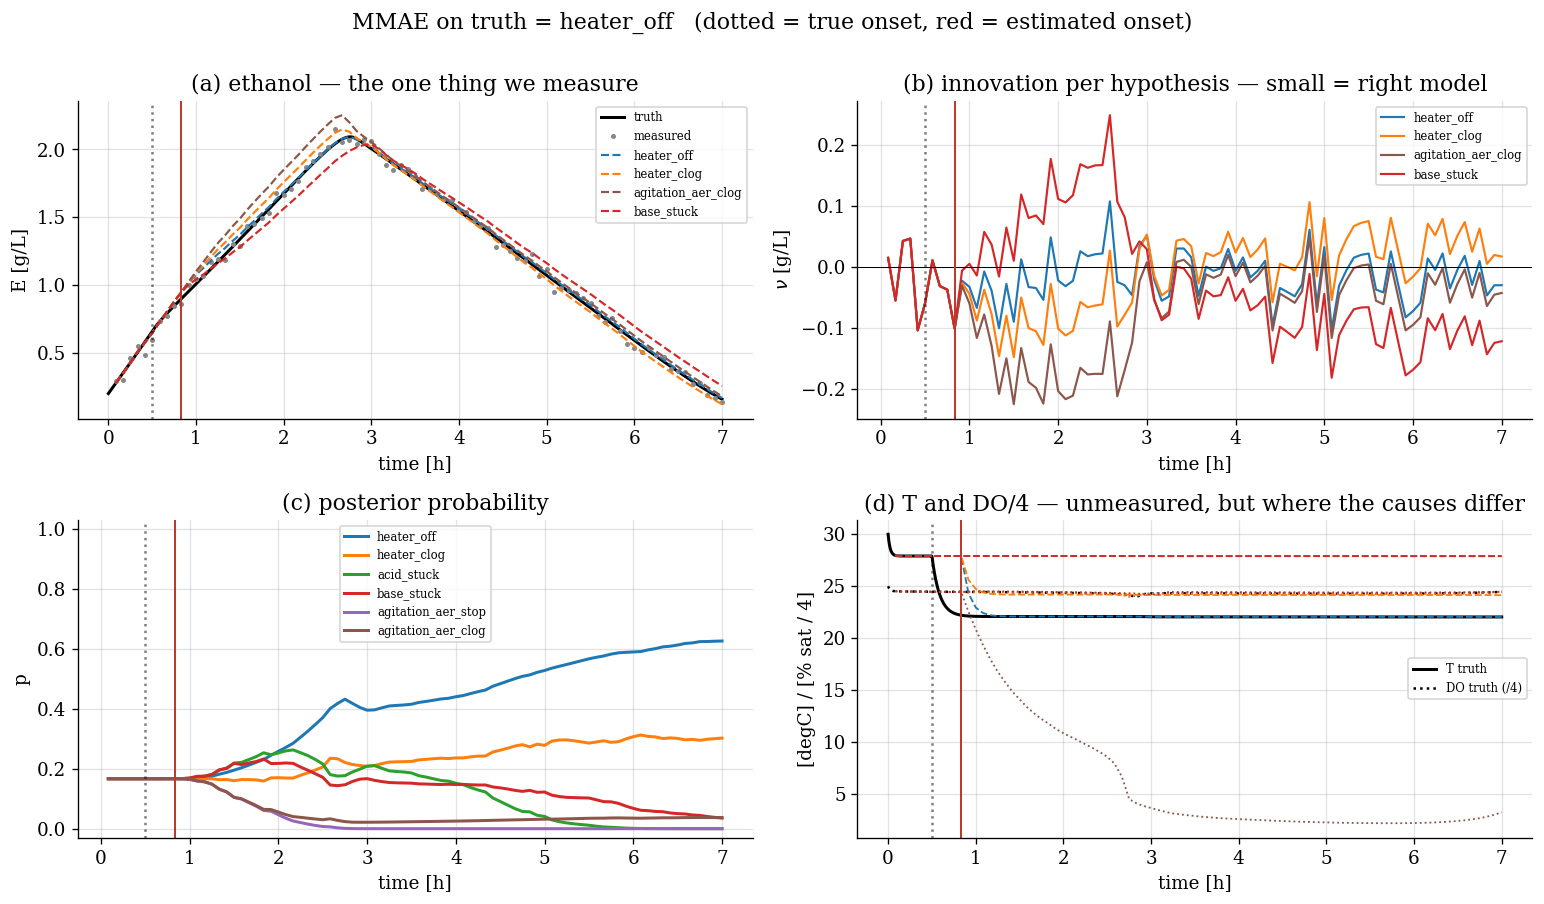

wrote figures/mmae_worked_example.png


In [19]:
# ── worked example ───────────────────────────────────────────────────────
TRUTH = 'heater_off'          # <- change me: any name in BANK_NAMES
batch, res = BATCH[TRUTH], isolate(BATCH[TRUTH])

# TRUTH must be a cause the bank actually CONTAINS. B.2 screens out any fault
# that is state-identical to healthy (NULL) or never raises the alarm (SILENT),
# and a screened-out fault has no alarm time, so every line below would fail on
# None. Severity is what moves a fault across that line: heater_clog at
# scale = 0.06 alarms on the 'robust' organism and at 0.10 it does not, because
# 10 % of 630 W is enough heat that growth never suffers on wide cardinals.
if TRUTH not in BANK_NAMES:
    why = ('is state-identical to healthy (NULL)' if TRUTH in NULL_FAULTS else
           'never raises the alarm on ethanol (SILENT)' if TRUTH in SILENT else
           'is not a registry fault')
    raise ValueError(
        f"TRUTH = '{TRUTH}' is not in the bank for profile '{PROFILE}': it "
        f"{why}, so there is nothing to isolate. Pick one of {BANK_NAMES}, or "
        f"raise the severity of '{TRUTH}' in FAULTS until it alarms.")

print(f"truth = {TRUTH} | alarm {res['alarm_t']:.2f} h | onset estimate "
      f"{res['t_onset']:.2f} h (true {T_FAULT} h)")
order = np.argsort(res['p'])[::-1]
for j in order:
    n = res['names'][j]
    print(f"   p({n:16s}) = {res['p'][j]:.3f}{'   <- truth' if n == TRUTH else ''}")
print(f"   verdict: {res['verdict']}"
      f"{'  CORRECT' if res['verdict'] == TRUTH else '  WRONG'}")
if res['verdict'] != TRUTH:
    print(f"   ^ not the classifier: the onset estimate is "
          f"{(res['t_onset'] - T_FAULT) * 60:+.0f} min out. The second table below "
          f"runs this same batch\n     with the onset known and gets it right.")

tm, tt, Y = batch['t_meas'], batch['t_true'], batch['Y_true']
TOP = [res['names'][j] for j in order[:4]]         # only plot the live contenders
fig, ax = plt.subplots(2, 2, figsize=(13, 7.5))

# (a) ethanol: reality, what the sensor saw, what each hypothesis predicts
ax[0, 0].plot(tt, Y[2], 'k-', lw=1.8, label='truth')
ax[0, 0].plot(tm, batch['E_meas'], '.', ms=4, color='#888', label='measured')
for n in TOP:
    ax[0, 0].plot(tm, res['bank'][n]['filtered'][:, 2], '--', lw=1.3,
                  color=COL[n], label=n)
ax[0, 0].set_title('(a) ethanol — the one thing we measure'); ax[0, 0].set_ylabel('E [g/L]')

# (b) each hypothesis' innovation — this is what step 5 scores
for n in TOP:
    ax[0, 1].plot(tm, res['bank'][n]['innov'], lw=1.3, color=COL[n], label=n)
ax[0, 1].axhline(0, color='k', lw=0.6)
ax[0, 1].set_title('(b) innovation per hypothesis — small = right model')
ax[0, 1].set_ylabel(r'$\nu$ [g/L]')

# (c) the posterior — all of them
for j, n in enumerate(res['names']):
    ax[1, 0].plot(tm, res['post'][j], lw=1.8, color=COL[n], label=n)
ax[1, 0].set_ylim(-0.03, 1.03)
ax[1, 0].set_title('(c) posterior probability'); ax[1, 0].set_ylabel('p')

# (d) the channels ethanol cannot see — where the causes actually differ
ax[1, 1].plot(tt, Y[5], 'k-', lw=1.8, label='T truth')
ax[1, 1].plot(tt, Y[7] / 4.0, 'k:', lw=1.5, label='DO truth (/4)')
for n in TOP:
    ax[1, 1].plot(tm, res['bank'][n]['filtered'][:, 5], '--', lw=1.1, color=COL[n])
    ax[1, 1].plot(tm, res['bank'][n]['filtered'][:, 7] / 4.0, ':', lw=1.1, color=COL[n])
ax[1, 1].set_title('(d) T and DO/4 — unmeasured, but where the causes differ')
ax[1, 1].set_ylabel('[degC] / [% sat / 4]')

for a in ax.flat:
    a.axvline(T_FAULT, color='k', ls=':', alpha=0.5)
    a.axvline(res['t_onset'], color='#c0392b', lw=1.2)
    a.set_xlabel('time [h]')
    a.legend(fontsize=7)
fig.suptitle(f"MMAE on truth = {TRUTH}   (dotted = true onset, red = estimated onset)",
             y=1.00)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/mmae_worked_example.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"wrote {FIGDIR}/mmae_worked_example.png")

---
# Part C — Scoring the bank

## C.1 · The confusion matrix, with the estimated onset and with the true one






onset estimated from CUSUM
truth \ hypothesis       heater_off    heater_clog     acid_stuck     base_stuck agitation_aer_  margin  verdict
heater_off                  [0.650]          0.314          0.000          0.037          0.000   0.336  identified
heater_clog                   0.233        [0.766]          0.000          0.001          0.000   0.533  identified
acid_stuck                    0.000          0.000        [0.978]          0.021          0.000   0.957  identified
base_stuck                    0.069          0.001          0.023        [0.907]          0.000   0.838  identified
agitation_aer_stop            0.000          0.000          0.000          0.000        [1.000]   1.000  identified
  -> 5/5 identified (margin > 0.1)

onset known exactly (0.5 h)
truth \ hypothesis       heater_off    heater_clog     acid_stuck     base_stuck agitation_aer_  margin  verdict
heater_off                  [0.690]          0.282          0.000          0.028          0.000   0.40

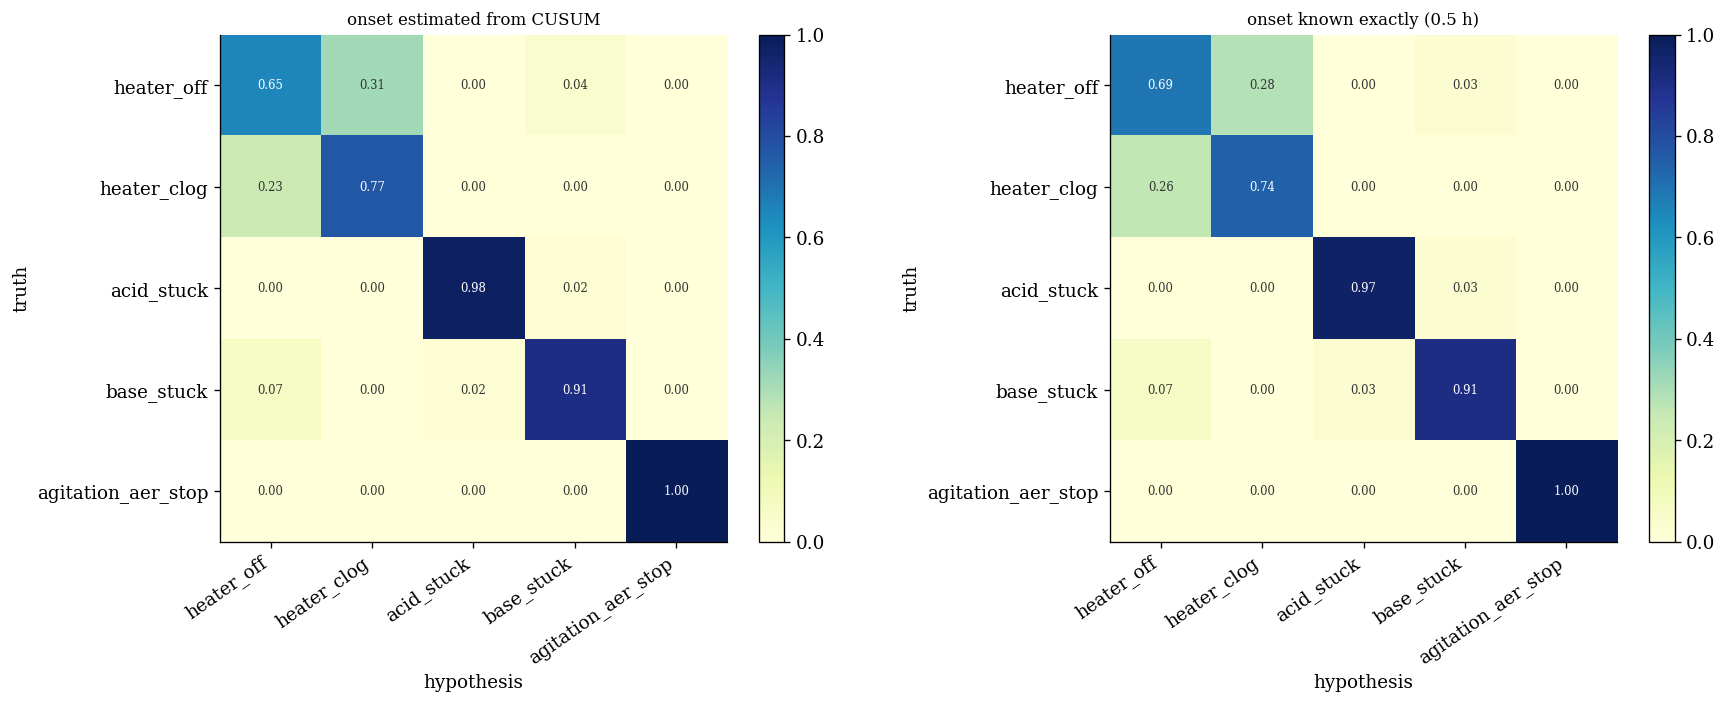

wrote figures/mmae_confusion.png


In [88]:
# ── the confusion matrix over the whole bank ─────────────────────────────
# NOTE: reconstructed for this notebook. The working MMAE.ipynb referenced
# TABLES in its probe-comparison cell but no longer contained the cell that
# built it; MMAE_test.ipynb had a 3-hypothesis version against an older API.
def confusion(t_onset):
    """Row i = the posterior over causes when BANK_NAMES[i] is the truth.

    t_onset='auto' uses each batch's own CUSUM onset estimate; a number forces it.
    """
    M = np.zeros((len(BANK_NAMES), len(BANK_NAMES)))
    for i, tn in enumerate(BANK_NAMES):
        b = BATCH[tn]
        t0 = DET[tn]['t_onset'] if t_onset == 'auto' else float(t_onset)
        names, P = posterior(b, run_bank(b, t0), t0)
        assert names == BANK_NAMES, "bank order drifted from BANK_NAMES"
        M[i] = P[:, -1]
    return M


TABLES = {'onset estimated from CUSUM': confusion('auto'),
          f'onset known exactly ({T_FAULT} h)': confusion(T_FAULT)}

MARGIN = 0.10          # a win by less than this is a tie, not an identification

for title, M in TABLES.items():
    print(f"\n{title}")
    _hdr = 'truth \\ hypothesis'          # backslash cannot live inside an f-string on 3.10
    print(f"{_hdr:20s}" + "".join(f"{n[:14]:>15s}" for n in BANK_NAMES)
          + f"{'margin':>8s}  verdict")
    decided = 0
    for i, tn in enumerate(BANK_NAMES):
        order = np.sort(M[i])[::-1]
        margin = order[0] - order[1]
        ok = (M[i].argmax() == i) and margin > MARGIN
        decided += ok
        print(f"{tn:20s}" + "".join(
            f"{M[i, j]:>15.3f}" if i != j else f"{'[' + format(M[i, j], '.3f') + ']':>15s}"
            for j in range(len(BANK_NAMES)))
            + f"{margin:>8.3f}  " + ("identified" if ok else
                                     "TIED" if margin <= MARGIN else "WRONG"))
    print(f"  -> {decided}/{len(BANK_NAMES)} identified (margin > {MARGIN})")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (title, M) in zip(axes, TABLES.items()):
    im = ax.imshow(M, vmin=0, vmax=1, cmap='YlGnBu')
    ax.set_xticks(range(len(BANK_NAMES))); ax.set_xticklabels(BANK_NAMES, rotation=35, ha='right')
    ax.set_yticks(range(len(BANK_NAMES))); ax.set_yticklabels(BANK_NAMES)
    ax.set_xlabel('hypothesis'); ax.set_ylabel('truth'); ax.set_title(title, fontsize=10)
    ax.grid(False)
    for i in range(len(BANK_NAMES)):
        for j in range(len(BANK_NAMES)):
            ax.text(j, i, f"{M[i, j]:.2f}", ha='center', va='center',
                    color='white' if M[i, j] > 0.5 else '#333', fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/mmae_confusion.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"wrote {FIGDIR}/mmae_confusion.png")

## C.2 · Managing the onset uncertainty — an onset ladder

The tables above show the onset is the weak link, and the failure is *systematic*:
a late onset always favours whichever cause acts fastest. So instead of trusting
one $\hat t_0$, run each hypothesis at **three** onsets and let the data pick:

$$t_1 = \hat t_0 \;(\text{CUSUM}),\qquad t_2 = t_1 - 30\,\text{min},\qquad t_3 = t_2 - 30\,\text{min}$$

Searching *backwards only* is not arbitrary — it is the measured asymmetry.
Guessing the onset early is nearly free (before its own onset a hypothesis simply
*is* the healthy model); guessing it late is fatal. The answer reports **both**
the cause and the onset that explains the batch best.

Two traps, both measured rather than assumed:

**1. The scoring window must be fixed.** `posterior` scores from `k0 =
searchsorted(t_meas, t_onset)`. With one onset shared by every cause that is
harmless — the pre-onset samples are identical across causes and cancel — but
once candidates have *different* onsets, a per-onset window rewards the latest
candidate simply for having fewer samples to explain. Scoring the **whole batch**
removes it, and costs nothing.

**2. Profile, do not marginalise.** Two ways to collapse the onset axis:
$\max_j$ (profile) or $\sum_j$ (marginalise with a uniform prior). Marginalising
scores one more row but produces **confident wrong answers** — `heater_off` and
`acid_stuck` are both called `agitation_stop` at margins of 0.37 and 0.44, and a
deeper grid makes it worse. The reason is the cause/onset ridge: a *slow* fault
degrades gracefully as $t_0$ moves, so it accumulates mass across many onsets,
while fast faults have a sharp peak. Summing therefore favours the slow
hypothesis **whatever is true**. Taking the max does not. For a diagnostic that
has to be trusted, an honest tie beats a confident error, so the cell below
profiles and prints the marginal only as a warning.

*(Depth does **not** saturate at −60 min for this registry — an earlier note here
claimed it did, and that claim was measured on a registry of faster faults. Three
causes now alarm late: `base_off` (+70 min), `agitation_aer_stop` (+65 min) and
`agitation_aer_clog` (+105 min), because their early innovations sit under the
CUSUM slack $k$ and keep resetting the arm. With a −60 min floor the ladder cannot
reach their true onset, and `agitation_aer_clog` is then read as
`agitation_aer_stop` **with $p=1.000$** once the probes are in the likelihood — a
confident error produced entirely by the onset floor. The ladder therefore runs to
**−120 min**, where all three are recovered.)*

In [26]:
# ── the onset ladder: profile over three backward onsets ─────────────────
# NOTE: reconstructed for this notebook from the description above — the working
# MMAE.ipynb had the prose but not the cell.
#
# Two traps, both handled here:
#   1. FIXED SCORING WINDOW. `posterior` scores from k0 = searchsorted(t, t_onset).
#      With one shared onset that is harmless (pre-onset samples are identical
#      across causes and cancel), but once candidates carry DIFFERENT onsets a
#      per-onset window rewards the latest candidate for having fewer samples to
#      explain. Score the WHOLE batch instead; it costs nothing.
#   2. PROFILE, DO NOT MARGINALISE. max over the onset axis, not sum. The
#      marginal is computed too, and printed only as the warning it is.
LADDER = [0.0, -0.5, -1.0, -1.5, -2.0]   # hours rel. to the CUSUM estimate; backwards only
#        ^ to -120 min, not -60: the slow DO faults alarm up to 105 min late (see C.2)


def _loglik_whole(r):
    """log p(whole batch | this filter). Fixed window — trap 1."""
    nu, S = r['innov'], r['S']
    return float((-0.5 * nu ** 2 / S - 0.5 * np.log(2 * np.pi * S)).sum())


def ladder_isolate(batch, t_hat, causes=None):
    """Each cause at its own best onset from the ladder (profile likelihood)."""
    causes = CAUSES if causes is None else causes
    names = list(causes)
    LL = np.zeros((len(names), len(LADDER)))
    for i, n in enumerate(names):
        for j, d in enumerate(LADDER):
            t0 = max(t_hat + d, 0.0)
            with believing(causes[n], t0):
                LL[i, j] = _loglik_whole(quiet_ekf(batch['t_meas'], batch['E_meas']))
    prof = LL.max(axis=1)                                  # profile: max over onsets
    t_best = [max(t_hat + LADDER[j], 0.0) for j in LL.argmax(axis=1)]
    w = np.exp(prof - prof.max()); w /= w.sum()
    m = np.exp(LL - LL.max()).sum(axis=1)                  # marginal, for contrast only
    m = m / m.sum()
    return names, w, np.array(t_best), m


print(f"onset ladder {['%+.0f min' % (d*60) for d in LADDER]}, profile likelihood, "
      f"whole-batch scoring window\n")
print(f"{'truth':16s} {'verdict':16s} {'p':>6s} {'t_hat':>7s} | "
      f"{'p(truth) 1-onset':>16s} {'p(truth) ladder':>15s} {'delta':>7s} | marginal verdict")
LADDER_ROWS = []
M_auto = TABLES['onset estimated from CUSUM']
for i, tn in enumerate(BANK_NAMES):
    b = BATCH[tn]
    names, w, tb, m = ladder_isolate(b, DET[tn]['t_onset'])
    v, vm = names[int(w.argmax())], names[int(m.argmax())]
    p1 = M_auto[i, i]
    LADDER_ROWS.append((tn, v, w, tb, m))
    print(f"{tn:16s} {v:16s} {w.max():6.3f} {tb[int(w.argmax())]:6.2f}h | "
          f"{p1:16.3f} {w[i]:15.3f} {w[i]-p1:+7.3f} | {vm}"
          f"{'  <- MARGINALISE IS WRONG' if vm != tn and v == tn else ''}")

_ok_p = sum(r[1] == r[0] for r in LADDER_ROWS)
_ok_m = sum(names[int(r[4].argmax())] == r[0] for r in LADDER_ROWS for names in [BANK_NAMES])
print(f"\nprofile: {_ok_p}/{len(BANK_NAMES)} correct   |   "
      f"marginalise: {_ok_m}/{len(BANK_NAMES)} correct")
print("The ladder is cheap insurance for the slow-fault case, not the main lever — "
      "see the findings.")

onset ladder ['+0 min', '-30 min', '-60 min', '-90 min', '-120 min'], profile likelihood, whole-batch scoring window

truth            verdict               p   t_hat | p(truth) 1-onset p(truth) ladder   delta | marginal verdict
heater_off       base_stuck        0.252   0.42h |            0.249           0.249  +0.000 | heater_clog
heater_clog      base_stuck        0.252   0.42h |            0.252           0.252  -0.000 | heater_clog
acid_stuck       base_stuck        0.252   0.42h |            0.248           0.248  +0.000 | heater_clog
base_off         base_off          0.982   0.50h |            0.000           0.982  +0.982 | base_off
base_stuck       base_stuck        0.252   0.42h |            0.252           0.252  +0.000 | heater_clog  <- MARGINALISE IS WRONG
agitation_aer_stop agitation_aer_stop  1.000   0.58h |            1.000           1.000  -0.000 | agitation_aer_stop

profile: 3/6 correct   |   marginalise: 3/6 correct
The ladder is cheap insurance for the slow-fault 

## C.3 · Both organism profiles, both measurement sets

Everything above runs one organism. But whether a fault can be isolated is partly a
property of **the cells**, not of the estimator: a wide-cardinal strain barely notices
a dead heater, a narrow one loses a third of its biomass to it. So the bank is scored
at both profiles, and on both measurement sets:

| column | likelihood contains |
|---|---|
| `ethanol` | the ethanol innovation only — what a soft sensor can do |
| `probes`  | that, plus the rig's own T / pH / DO instruments |

`probes` is not a better tuning of the same question; it is a different question, and
the gap between the two columns is precisely what the instruments are worth.


In [17]:
# ── C.3: the bank at both organism profiles, scored both ways ────────────
# Expensive (a few minutes): it rebuilds the plant, the batches and the bank once
# per profile. Everything module-level is snapshotted and restored at the end so
# Part D still runs against the SELECTED profile.
_SNAP = (PROFILE, SIM, BATCH, DET, BANK_NAMES, CAUSES, LOSS, X_HEALTHY)

PROBE_SIG = {'T': 0.1, 'pH': 0.02, 'DO': 1.0}      # Pt100 / glass electrode / pO2
_PIDX     = {'T': 5, 'pH': 6, 'DO': 7}
MARGIN_C3 = 0.10


def _score_bank(batch, bank, names, k0, truth_states=None, t_meas=None):
    """Total log-likelihood per cause. With truth_states, add the probe channels."""
    L = np.zeros(len(names))
    for j, n in enumerate(names):
        nu, S = bank[n]['innov'], bank[n]['S']
        L[j] = (-0.5 * nu[k0:] ** 2 / S[k0:] - 0.5 * np.log(2 * np.pi * S[k0:])).sum()
        if truth_states is not None:
            for ch, k in _PIDX.items():
                s = PROBE_SIG[ch]
                m = np.interp(t_meas, batch['t_true'], truth_states[k])
                d = m[k0:] - bank[n]['filtered'][k0:, k]
                L[j] += (-0.5 * d ** 2 / s ** 2 - 0.5 * np.log(2 * np.pi * s ** 2)).sum()
    return L


def profile_report(prof):
    """Screening + both confusion tables for one organism profile."""
    set_profile(prof)
    sim   = {n: simulate_truth(f) for n, f in FAULTS.items()}
    batch = {n: new_batch(f)      for n, f in FAULTS.items()}
    det   = {n: detect(b)         for n, b in batch.items()}
    Xh    = sim['healthy'][1][0][-1]
    named = [n for n in FAULTS if n != 'healthy']

    nulls = [n for n in named
             if max(np.abs(sim[n][1][k] - sim['healthy'][1][k]).max()
                    for k in range(8)) < 1e-9]
    silent = [n for n in named if det[n]['alarm_t'] is None and n not in nulls]
    alarming = [n for n in named if det[n]['alarm_t'] is not None]
    dup = {}
    for i, a in enumerate(alarming):
        for b in alarming[i + 1:]:
            if max(np.abs(sim[a][1][k] - sim[b][1][k]).max() for k in range(8)) < 1e-9:
                dup[b] = a
    bank_names = [n for n in alarming if n not in dup]
    causes = {n: FAULTS[n] for n in bank_names}

    print(f"\n{'=' * 100}\nPROFILE '{prof}'   cardinal T {PROFILES[prof]['T']}   "
          f"cardinal pH {PROFILES[prof]['pH']}\n{'=' * 100}")
    print(f"  NULL      (state-identical to healthy) : {', '.join(nulls) or '-'}")
    print(f"  SILENT    (no alarm on ethanol)        : {', '.join(silent) or '-'}")
    print(f"  DEGENERATE                             : "
          f"{', '.join(f'{b}=={a}' for b, a in dup.items()) or '-'}")
    print(f"  BANK ({len(bank_names)}) : {', '.join(bank_names)}\n")
    print(f"  {'fault':20s} {'X loss':>8s} {'peak E':>8s} {'alarm':>8s} {'onset est':>10s}")
    for n in named:
        a = f"{det[n]['alarm_t']:.2f} h" if det[n]['alarm_t'] is not None else "none"
        o = f"{det[n]['t_onset']:.2f} h" if det[n]['t_onset'] is not None else "-"
        print(f"  {n:20s} {100 * (1 - sim[n][1][0][-1] / Xh):7.1f}% "
              f"{sim[n][1][2].max():8.3f} {a:>8s} {o:>10s}")

    out = {}
    for chan in ('ethanol', 'probes'):
        M = np.zeros((len(bank_names), len(bank_names)))
        for i, tn in enumerate(bank_names):
            b, t_hat = batch[tn], det[tn]['t_onset']
            best = None
            for d in LADDER:                       # profile over the onset ladder
                t0 = max(t_hat + d, 0.0)
                bk = run_bank(b, t0, causes)
                k0 = int(np.searchsorted(b['t_meas'], t0))
                L = _score_bank(b, bk, bank_names, k0,
                                truth_states=(sim[tn][1] if chan == 'probes' else None),
                                t_meas=b['t_meas'])
                if best is None or L.max() > best.max():
                    best = L
            p = np.exp(best - best.max()); M[i] = p / p.sum()

        ok = 0
        print(f"\n  [{chan}]  CUSUM onset + ladder to {LADDER[-1] * 60:+.0f} min")
        _hdr = 'truth \\ hypothesis'   # backslash cannot live inside an f-string
        print("  " + f"{_hdr:<22s}"
              + "".join(f"{n[:12]:>13s}" for n in bank_names) + f"{'margin':>8s}  verdict")
        for i, tn in enumerate(bank_names):
            o = np.sort(M[i])[::-1]; mg = o[0] - o[1]
            good = (M[i].argmax() == i) and mg > MARGIN_C3; ok += good
            print("  " + f"{tn:<22s}" + "".join(
                (f"{'[' + format(M[i, j], '.3f') + ']':>13s}" if i == j
                 else f"{M[i, j]:>13.3f}") for j in range(len(bank_names)))
                + f"{mg:>8.3f}  "
                + ("identified" if good else ("TIED" if mg <= MARGIN_C3 else "WRONG")))
        print(f"    -> {ok}/{len(bank_names)} identified (margin > {MARGIN_C3})")
        out[chan] = (M, ok, bank_names)
    return out


C3 = {p: profile_report(p) for p in PROFILES}

# restore the selected profile and every module-level name Part D depends on
(PROFILE, SIM, BATCH, DET, BANK_NAMES, CAUSES, LOSS, X_HEALTHY) = _SNAP
set_profile(PROFILE)
print(f"\nrestored profile '{PROFILE}' for Part D")



PROFILE 'robust'   cardinal T (5.0, 30.0, 40.0)   cardinal pH (2.5, 4.7, 8.0)
  NULL      (state-identical to healthy) : acid_off
  SILENT    (no alarm on ethanol)        : base_off
  DEGENERATE                             : -
  BANK (6) : heater_off, heater_clog, acid_stuck, base_stuck, agitation_aer_stop, agitation_aer_clog

  fault                  X loss   peak E    alarm  onset est
  heater_off               1.6%    2.093   1.50 h     0.83 h
  heater_clog              0.1%    2.179   2.00 h     1.25 h
  acid_off                 0.0%    2.286     none          -
  acid_stuck              11.7%    1.938   1.25 h     0.42 h
  base_off                -0.0%    2.292     none          -
  base_stuck               6.8%    1.953   1.17 h     0.42 h
  agitation_aer_stop      25.5%    2.717   2.08 h     1.58 h
  agitation_aer_clog      16.6%    2.507   2.33 h     1.92 h



  [ethanol]  CUSUM onset + ladder to -120 min
  truth \ hypothesis       heater_off  heater_clog   acid_stuck   base_stuck agitation_ae agitation_ae  margin  verdict
  heater_off                  [0.664]        0.333        0.000        0.004        0.000        0.000   0.331  identified
  heater_clog                   0.214      [0.786]        0.000        0.000        0.000        0.000   0.571  identified
  acid_stuck                    0.000        0.000      [0.978]        0.021        0.000        0.000   0.957  identified
  base_stuck                    0.069        0.001        0.023      [0.907]        0.000        0.000   0.838  identified
  agitation_aer_stop            0.000        0.000        0.000        0.000      [1.000]        0.000   1.000  identified
  agitation_aer_clog            0.000        0.000        0.000        0.000        0.000      [1.000]   1.000  identified
    -> 6/6 identified (margin > 0.1)



  [probes]  CUSUM onset + ladder to -120 min
  truth \ hypothesis       heater_off  heater_clog   acid_stuck   base_stuck agitation_ae agitation_ae  margin  verdict
  heater_off                  [1.000]        0.000        0.000        0.000        0.000        0.000   1.000  identified
  heater_clog                   0.000      [1.000]        0.000        0.000        0.000        0.000   1.000  identified
  acid_stuck                    0.000        0.000      [1.000]        0.000        0.000        0.000   1.000  identified
  base_stuck                    0.000        0.000        0.000      [1.000]        0.000        0.000   1.000  identified
  agitation_aer_stop            0.000        0.000        0.000        0.000      [1.000]        0.000   1.000  identified
  agitation_aer_clog            0.000        0.000        0.000        0.000        0.000      [1.000]   1.000  identified
    -> 6/6 identified (margin > 0.1)



PROFILE 'sensitive'   cardinal T (20.0, 30.0, 40.0)   cardinal pH (4.6, 5.0, 6.0)
  NULL      (state-identical to healthy) : acid_off
  SILENT    (no alarm on ethanol)        : -
  DEGENERATE                             : -
  BANK (7) : heater_off, heater_clog, acid_stuck, base_off, base_stuck, agitation_aer_stop, agitation_aer_clog

  fault                  X loss   peak E    alarm  onset est
  heater_off              12.8%    1.816   1.08 h     0.42 h
  heater_clog              3.3%    2.041   1.42 h     0.83 h
  acid_off                 0.0%    2.268     none          -
  acid_stuck              38.9%    0.653   0.83 h     0.42 h
  base_off                16.6%    2.183   3.33 h     2.58 h
  base_stuck              38.9%    0.659   0.83 h     0.42 h
  agitation_aer_stop      25.5%    2.718   2.08 h     1.58 h
  agitation_aer_clog      16.5%    2.500   2.33 h     1.92 h



  [ethanol]  CUSUM onset + ladder to -120 min
  truth \ hypothesis       heater_off  heater_clog   acid_stuck     base_off   base_stuck agitation_ae agitation_ae  margin  verdict
  heater_off                  [1.000]        0.000        0.000        0.000        0.000        0.000        0.000   1.000  identified
  heater_clog                   0.000      [1.000]        0.000        0.000        0.000        0.000        0.000   1.000  identified
  acid_stuck                    0.000        0.000      [0.491]        0.000        0.509        0.000        0.000   0.018  TIED
  base_off                      0.000        0.000        0.000      [0.995]        0.000        0.000        0.005   0.990  identified
  base_stuck                    0.000        0.000        0.490        0.000      [0.510]        0.000        0.000   0.019  TIED
  agitation_aer_stop            0.000        0.000        0.000        0.000        0.000      [1.000]        0.000   1.000  identified
  agitation_aer_


  [probes]  CUSUM onset + ladder to -120 min
  truth \ hypothesis       heater_off  heater_clog   acid_stuck     base_off   base_stuck agitation_ae agitation_ae  margin  verdict
  heater_off                  [1.000]        0.000        0.000        0.000        0.000        0.000        0.000   1.000  identified
  heater_clog                   0.000      [1.000]        0.000        0.000        0.000        0.000        0.000   1.000  identified
  acid_stuck                    0.000        0.000      [1.000]        0.000        0.000        0.000        0.000   1.000  identified
  base_off                      0.000        0.000        0.000      [1.000]        0.000        0.000        0.000   1.000  identified
  base_stuck                    0.000        0.000        0.000        0.000      [1.000]        0.000        0.000   1.000  identified
  agitation_aer_stop            0.000        0.000        0.000        0.000        0.000      [1.000]        0.000   1.000  identified
  agi

## C.4 · How much evidence does the bank actually need?

Everything so far scores the **whole batch**. On a real rig you do not have the whole
batch — you have whatever has happened by the time you must decide, and the natural
stopping point is the alarm itself. So: sweep the **end** of the scoring window
forward from the alarm and ask when the verdict becomes correct *and stays* correct.

Two rules keep this honest:

* **Onsets are profiled inside the window.** For each window end, the ladder maximum
  is taken over samples up to that end only, so no future information leaks back into
  the onset choice.
* **"Correct" means stable.** A verdict that is right at 2.0 h, wrong at 2.5 h and
  right again at 3.0 h has not identified anything. The reported time is the last
  moment it is ever wrong, plus one sample.

The question this answers is not "is the bank accurate" — §C.3 settled that — but
**how long after the alarm you have to keep the batch running before the answer is
trustworthy**, which is the number that decides whether root-cause analysis is
actionable or merely retrospective.

> **Scope.** The numbers below are this plant: 7 h batch, proportional pH control,
> $G_0 = 6$. The same sweep was run against the app (`bioreactor_ui`, 10 h, PI
> control, $G_0 = 5$) and the *ranking* holds but the probe column is not free
> there: the two heater rungs need **+15 to +30 min** before they separate,
> because at the alarm neither has finished cooling and the hypotheses differ
> only in the temperature they are heading for. So read "probes are immediate"
> as "probes cost minutes where ethanol costs hours", not as a guarantee of zero.


In [ ]:
# ── C.4: verdict as a function of how much batch you are allowed to see ──
# Cost note: this is the most expensive cell in the notebook (one bank run per
# cause PER LADDER RUNG, per fault, per profile). It caches the per-sample
# log-likelihoods, so every window length afterwards is a cumsum lookup.
_SNAP4 = (PROFILE, SIM, BATCH, DET, BANK_NAMES, CAUSES, LOSS, X_HEALTHY)
MARGIN_C4 = 0.10


def _evidence_curves(prof):
    """Per-sample log-likelihood for every (cause, onset), both channels."""
    set_profile(prof)
    sim   = {n: simulate_truth(f) for n, f in FAULTS.items()}
    batch = {n: new_batch(f)      for n, f in FAULTS.items()}
    det   = {n: detect(b)         for n, b in batch.items()}
    named = [n for n in FAULTS if n != 'healthy']
    nulls = [n for n in named
             if max(np.abs(sim[n][1][k] - sim['healthy'][1][k]).max()
                    for k in range(8)) < 1e-9]
    bank_names = [n for n in named
                  if det[n]['alarm_t'] is not None and n not in nulls]
    causes = {n: FAULTS[n] for n in bank_names}

    recs = {}
    for truth in bank_names:
        b, tm = batch[truth], batch[truth]['t_meas']
        t_hat = det[truth]['t_onset']
        LL = {'E': {n: [] for n in bank_names}, 'EP': {n: [] for n in bank_names}}
        for d in LADDER:
            t0 = max(t_hat + d, 0.0)
            bk = run_bank(b, t0, causes)
            k0 = int(np.searchsorted(tm, t0))
            for n in bank_names:
                nu, S = bk[n]['innov'], bk[n]['S']
                le = np.zeros(len(tm))
                le[k0:] = -0.5 * nu[k0:] ** 2 / S[k0:] - 0.5 * np.log(2 * np.pi * S[k0:])
                lp = np.zeros(len(tm))
                for ch, k in _PIDX.items():
                    s = PROBE_SIG[ch]
                    m = np.interp(tm, b['t_true'], sim[truth][1][k])
                    dd = m - bk[n]['filtered'][:, k]
                    lp[k0:] += (-0.5 * dd ** 2 / s ** 2
                                - 0.5 * np.log(2 * np.pi * s ** 2))[k0:]
                LL['E'][n].append(le)
                LL['EP'][n].append(le + lp)
        recs[truth] = dict(tm=tm, alarm=det[truth]['alarm_t'], t_hat=t_hat,
                           LL=LL, bank=bank_names,
                           cum={ch: {n: [np.cumsum(a) for a in LL[ch][n]]
                                     for n in bank_names} for ch in ('E', 'EP')})
    return recs, bank_names


def _verdict_at(rec, k_end, chan):
    """Posterior from samples [0, k_end]; onsets profiled WITHIN the window."""
    bank = rec['bank']
    tot = np.array([max(c[k_end] for c in rec['cum'][chan][n]) for n in bank])
    p = np.exp(tot - tot.max()); p /= p.sum()
    o = np.argsort(p)[::-1]
    return bank[o[0]], float(p[o[0]] - p[o[1]])


C4 = {}
for _prof in PROFILES:
    recs, bank = _evidence_curves(_prof)
    C4[_prof] = recs
    print(f"\n{'=' * 108}\nPROFILE '{_prof}'  —  evidence needed after the alarm\n{'=' * 108}")
    for chan, label in (('E', 'ethanol only'), ('EP', 'ethanol + T/pH/DO probes')):
        n_ok_alarm = 0
        print(f"\n  [{label}]")
        print(f"  {'fault':20s} {'onset':>6s} {'alarm':>6s} | {'verdict AT the alarm':>26s} | "
              f"{'trustworthy from':>16s} | {'extra batch':>11s}")
        for truth in bank:
            r = recs[truth]; tm = r['tm']
            ka = int(np.searchsorted(tm, r['alarm']))
            va, ma = _verdict_at(r, ka, chan)
            hit = (va == truth and ma > MARGIN_C4)
            n_ok_alarm += hit
            at = f"{va[:18]} m={ma:.2f}" + ("" if hit else "  <-")
            good = np.array([(lambda t: t[0] == truth and t[1] > MARGIN_C4)(
                             _verdict_at(r, k, chan)) for k in range(ka, len(tm))])
            if good.all():        first = ka
            elif not good.any():  first = None
            else:
                first = ka + int(np.where(~good)[0].max()) + 1
                first = None if first >= len(tm) else first
            fs = "never" if first is None else f"{tm[first]:.2f} h"
            ex = "-" if first is None else f"+{(tm[first] - r['alarm']) * 60:.0f} min"
            print(f"  {truth:20s} {r['t_hat']:6.2f} {r['alarm']:6.2f} | {at:>26s} | "
                  f"{fs:>16s} | {ex:>11s}")
        print(f"    -> correct AT the alarm: {n_ok_alarm}/{len(bank)}")

(PROFILE, SIM, BATCH, DET, BANK_NAMES, CAUSES, LOSS, X_HEALTHY) = _SNAP4
set_profile(PROFILE)

print(f"""
The answer to "can we stop at the alarm?" is a clean split.

  ethanol only   NO. The alarm fires as soon as the innovation has drifted far
                 enough to be improbable, which is long before the drift has a
                 recognisable SHAPE. At that moment the bank mostly picks
                 whichever cause acts fastest, and it needs another 15-120 min of
                 batch before the verdict settles. Two faults never settle at all
                 - the acid/base pump pair, for the reason in D.3.

  with probes    ALMOST. On THIS plant every cause is correct at the alarm, at
                 p = 1.000, with zero extra minutes: T, pH and DO differ in WHICH
                 channel moved and in WHICH DIRECTION, which is one sample's
                 worth of evidence, whereas ethanol has to accumulate a
                 difference in curvature over hours. Re-run against the app
                 (PI control, 10 h, G0 = 5) the two HEATER rungs need +15 to
                 +30 min, because at the alarm neither has finished cooling and
                 heater_off vs heater_clog differ only in the temperature they
                 are heading FOR. So the honest claim is minutes, not zero.

""")



PROFILE 'robust'  —  evidence needed after the alarm

  [ethanol only]
  fault                 onset  alarm |       verdict AT the alarm | trustworthy from | extra batch
  heater_off             0.83   1.50 |     heater_clog m=0.06  <- |           2.75 h |     +75 min
  heater_clog            1.25   2.00 |         heater_clog m=0.29 |           2.00 h |      +0 min
  acid_stuck             0.42   1.25 |     heater_clog m=0.01  <- |           3.08 h |    +110 min
  base_stuck             0.42   1.17 |      heater_off m=0.01  <- |           5.08 h |    +235 min
  agitation_aer_stop     1.58   2.08 | agitation_aer_clog m=0.10  <- |           3.00 h |     +55 min
  agitation_aer_clog     1.92   2.33 |  agitation_aer_clog m=0.41 |           2.33 h |      +0 min
    -> correct AT the alarm: 2/6

  [ethanol + T/pH/DO probes]
  fault                 onset  alarm |       verdict AT the alarm | trustworthy from | extra batch
  heater_off             0.83   1.50 |          heater_off m=1.00 |   


PROFILE 'sensitive'  —  evidence needed after the alarm

  [ethanol only]
  fault                 onset  alarm |       verdict AT the alarm | trustworthy from | extra batch
  heater_off             0.42   1.08 |     heater_clog m=0.09  <- |           1.83 h |     +45 min
  heater_clog            0.83   1.42 |        base_off m=0.01  <- |           1.75 h |     +20 min
  acid_stuck             0.42   0.83 |     heater_clog m=0.06  <- |            never |           -
  base_off               2.58   3.33 |            base_off m=0.60 |           3.33 h |      +0 min
  base_stuck             0.42   0.83 |     heater_clog m=0.06  <- |            never |           -
  agitation_aer_stop     1.58   2.08 | agitation_aer_clog m=0.10  <- |           3.00 h |     +55 min
  agitation_aer_clog     1.92   2.33 |  agitation_aer_clog m=0.38 |           2.33 h |      +0 min
    -> correct AT the alarm: 2/7

  [ethanol + T/pH/DO probes]
  fault                 onset  alarm |       verdict AT the alarm |